# 02 MVP Engine – Conditional Gaussian Scenario Generator
**Aiden** · RBC Capital Markets Summer 2026  
Data source: `data/raw/Products_BB_Cleaned.xlsx` (Bloomberg, Mo's pull June 2026)  
Meeting ref: 06-18 with Mezan (futures roll, holiday policy, transform confirmation)

---


## §0  Setup & Config


In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path
import uuid
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yaml

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT       = Path('../..').resolve()
DATA_DIR   = ROOT / 'data' / 'raw'
CONFIG_DIR = ROOT / 'configs'
sys.path.insert(0, str(ROOT))

# ── Contracts (from src/) ─────────────────────────────────────────────────────
try:
    from src.rbc_scenario.engine.contracts import (
        PinnedShock, FactorScenario, ScenarioWarning, ScenarioResult
    )
    print('✓ contracts imported from src/')
except ImportError:
    # Fallback inline definitions (same schema)
    from dataclasses import dataclass, field
    from typing import Literal
    ShockUnit = Literal['return', 'bp', 'pct', 'price', 'price_diff']

    @dataclass(frozen=True)
    class PinnedShock:
        factor_id: str; shock_value: float; shock_unit: str

    @dataclass(frozen=True)
    class FactorScenario:
        factor_id: str; factor_name: str; asset_class: str; region: str
        currency: str; unit: str; is_pinned: bool; input_shock: object
        conditional_mean: float; conditional_volatility: float
        scenario_shock: float; percentile: object = None

    @dataclass(frozen=True)
    class ScenarioWarning:
        code: str; message: str; severity: str

    @dataclass(frozen=True)
    class ScenarioResult:
        scenario_id: str; method: str; factor_results: list
        diagnostics: dict = field(default_factory=dict)
        warnings: list  = field(default_factory=list)

    print('⚠ contracts loaded from inline fallback')

# ── Configs ───────────────────────────────────────────────────────────────────
with open(CONFIG_DIR / 'methods.yaml') as f:
    METHODS_CFG = yaml.safe_load(f)
with open(CONFIG_DIR / 'stress_episodes.yaml') as f:
    EPISODES_CFG = yaml.safe_load(f)

cg = METHODS_CFG['methods']['conditional_gaussian']
print(f"Default cov method : {cg['covariance_method']}")
print(f"Min observations   : {cg['min_observations']}")

print('\nMVP stress episodes:')
for ep in EPISODES_CFG['episodes']:
    star = ' ★ MVP' if ep['required_for_mvp'] else ''
    print(f"  {ep['episode_id']:30s}  {ep['start_date']} → {ep['end_date']}{star}")

# ── Style ─────────────────────────────────────────────────────────────────────
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'figure.figsize': (13, 5), 'font.size': 11, 'axes.titlesize': 12})
FIT_START = '2010-01-01'   # Chosen fit window start (see §8 for rationale)
print(f'\nFit window start: {FIT_START}')


⚠ contracts loaded from inline fallback


FileNotFoundError: [Errno 2] No such file or directory: '/Users/minoneshan/Github/RBC/configs/methods.yaml'

## §1  Data Loading — Bloomberg Cleaned

Three sheets from `Products_BB_Cleaned.xlsx`:
- **Metadata**: ticker definitions, asset class, prefix mapping  
- **Products**: quality stats (completion%, date range) per ticker  
- **Data**: daily OHLCV + OI for all 44 tickers (Date × fields)


In [ ]:
BB_PATH = DATA_DIR / 'Products_BB_Cleaned.xlsx'
xl = pd.ExcelFile(BB_PATH)

# ── Metadata ──────────────────────────────────────────────────────────────────
meta = pd.read_excel(xl, 'Metadata')
# Map: first word of ticker → full ticker  (handles "W 1 Comdty" → col "W__LAST")
meta['col_prefix'] = meta['Ticker'].str.split().str[0]
PREFIX_MAP = dict(zip(meta['col_prefix'], meta['Ticker']))
CAT_MAP    = dict(zip(meta['Ticker'], meta['future_category'].fillna('Unknown')))

# ── Products (quality stats) ──────────────────────────────────────────────────
prod = pd.read_excel(xl, 'Products')
prod = prod.rename(columns={'Data Completion %': 'completion_pct',
                             'Data Start': 'data_start', 'Data End': 'data_end'})
prod['data_start'] = pd.to_datetime(prod['data_start'])
prod['data_end']   = pd.to_datetime(prod['data_end'])
prod['years'] = (prod['data_end'] - prod['data_start']).dt.days / 365.25

# ── Data sheet ────────────────────────────────────────────────────────────────
raw = pd.read_excel(xl, 'Data', parse_dates=['Date'])
raw = raw.sort_values('Date').reset_index(drop=True)

# Identify field columns by suffix
last_cols   = [c for c in raw.columns if c.endswith('__LAST')]
vol_cols    = [c for c in raw.columns if c.endswith('__VOLUME')]
oi_cols     = [c for c in raw.columns if c.endswith('__OI')]

def col_to_ticker(col, suffix):
    prefix = col.replace(suffix, '')
    return PREFIX_MAP.get(prefix, prefix)

rename_last = {c: col_to_ticker(c, '__LAST')   for c in last_cols}
rename_vol  = {c: col_to_ticker(c, '__VOLUME') for c in vol_cols}
rename_oi   = {c: col_to_ticker(c, '__OI')     for c in oi_cols}

raw_prices = (raw[['Date'] + last_cols].rename(columns=rename_last)
              .set_index('Date').rename_axis('date'))
raw_volume = (raw[['Date'] + vol_cols].rename(columns=rename_vol)
              .set_index('Date').rename_axis('date'))
raw_oi     = (raw[['Date'] + oi_cols].rename(columns=rename_oi)
              .set_index('Date').rename_axis('date'))

print(f'Price panel : {raw_prices.shape[0]:,} rows × {raw_prices.shape[1]} tickers')
print(f'Volume panel: {raw_volume.shape[0]:,} rows × {raw_volume.shape[1]} tickers')
print(f'OI panel    : {raw_oi.shape[0]:,} rows × {raw_oi.shape[1]} tickers')
print(f'Date range  : {raw_prices.index.min().date()} → {raw_prices.index.max().date()}')
print(f'\nSample tickers mapped: {list(raw_prices.columns[:8])}')


Price panel : 5,207 rows × 44 tickers
Volume panel: 5,207 rows × 44 tickers
OI panel    : 5,207 rows × 44 tickers
Date range  : 2006-06-19 → 2026-06-18

Sample tickers mapped: ['CO1 Comdty', 'CL1 Comdty', 'NG1 Comdty', 'TZT1 Comdty', 'ZMI1 Comdty', 'ZEA1 Comdty', 'FN1 Comdty', 'QS1 Comdty']


## §2  Tier A Universe Screening

**Criteria (per project docs §03_methodology):** `completion% ≥ 90 AND years ≥ 10`

| Tier | Criteria | Action |
|------|---------|--------|
| A | completion ≥ 90%, years ≥ 10 | Use in MVP |
| B | completion 50–90% OR years 5–10 | Extension phase |
| C | years < 5 or very low completion | Exclude |
| D | No data | Skip (Mezan: "not critical") |


In [ ]:
def classify_tier(row):
    c, y = row['completion_pct'], row['years']
    if pd.isna(c) or pd.isna(y) or c == 0:
        return 'D'
    if c >= 90 and y >= 10:
        return 'A'
    if c >= 50 or y >= 5:
        return 'B'
    return 'C'

prod['tier'] = prod.apply(classify_tier, axis=1)

# Join with category from Metadata
prod = prod.merge(meta[['Ticker', 'future_category', 'col_prefix']],
                  on='Ticker', how='left')

tier_counts = prod['tier'].value_counts().sort_index()
print('Tier distribution:', dict(tier_counts))

# Display full table sorted by tier, completion
display_cols = ['Ticker', 'future_category', 'tier', 'completion_pct', 'data_start', 'data_end', 'years']
tier_table = prod[display_cols].sort_values(['tier', 'completion_pct'], ascending=[True, False])
print('\n', tier_table.to_string(index=False))

# Tier A tickers
TIER_A = prod[prod['tier'] == 'A']['Ticker'].tolist()
print(f'\nTier A tickers ({len(TIER_A)}):')
for t in TIER_A:
    print(f'  {t}')

# Fit window selection rationale
print('\n── Fit Window Rationale ──────────────────────────────────────────────────')
print(f'Mezan (06-18): "you\'re not really going to be able to fit on the full')
print(f'                history of like the longest dataset"')
print()
windows = [
    ('2006-2026 (full)', '2006-01-01', 'GFC + post-GFC + COVID + 2022 rates'),
    ('2010-2026 (chosen)', '2010-01-01', 'post-GFC + COVID + 2022 rates  ← RECOMMENDED'),
    ('2015-2026', '2015-01-01', 'modern regime only'),
]
for label, start, comment in windows:
    n = raw_prices.loc[start:, TIER_A].dropna().shape[0]
    print(f'  {label:20s} | {n:>5,} clean rows | {comment}')


Tier distribution: {'A': 34, 'B': 6, 'C': 3, 'D': 1}

      Ticker              future_category tier  completion_pct data_start   data_end     years
 QS1 Comdty Financial commodity generic.    A           99.25 2006-06-19 2026-06-17 19.994524
 FN1 Comdty Financial commodity generic.    A           99.17 2006-06-19 2026-06-17 19.994524
 CO1 Comdty                    Crude Oil    A           99.15 2006-06-19 2026-06-17 19.994524
 ER1 Comdty Financial commodity generic.    A           98.85 2006-06-19 2026-06-17 19.994524
TZT1 Comdty Financial commodity generic.    A           98.41 2006-06-19 2026-06-17 19.994524
 DU1 Comdty Financial commodity generic.    A           98.12 2006-06-19 2026-06-17 19.994524
 RX1 Comdty Financial commodity generic.    A           98.06 2006-06-19 2026-06-17 19.994524
  VG1 Index     Financial index generic.    A           98.04 2006-06-19 2026-06-17 19.994524
  NQ1 Index     Financial index generic.    A           97.29 2006-06-19 2026-06-18 19.997262
 TY1 

## §3  Holiday Missing-Value Policy Analysis

**Mezan (06-18):** "We definitely want alignment on dates... if there's a holiday, you just exclude that... but then maybe that'll take out too many data points. So I would just do that analysis."

Three strategies compared:
- **A — strict dropna**: any NaN in the cross-section → drop row  
- **B — ffill(3) + dropna** *(recommended)*: forward-fill up to 3 days (handles CME/LME/Eurex cross-holidays), then drop residual NaN  
- **C — threshold(30%) + ffill**: keep rows where ≤ 30% of tickers are missing, then ffill


Full panel rows: 5,207

                        Strategy  Rows kept Pct retained
                A: strict dropna       4584        88.0%
B: ffill(3)+dropna (recommended)       5178        99.4%
         C: threshold(30%)+ffill       5005        96.1%

Top 10 missing rate (raw, Tier A):
NO1 Index      6.41%
NG1 Comdty     3.25%
ZEA1 Comdty    3.25%
C 1 Comdty     3.25%
W 1 Comdty     3.25%
XB1 Comdty     3.25%
HO1 Comdty     3.25%
PA1 Comdty     3.25%
PL1 Comdty     3.25%
CL1 Comdty     3.23%


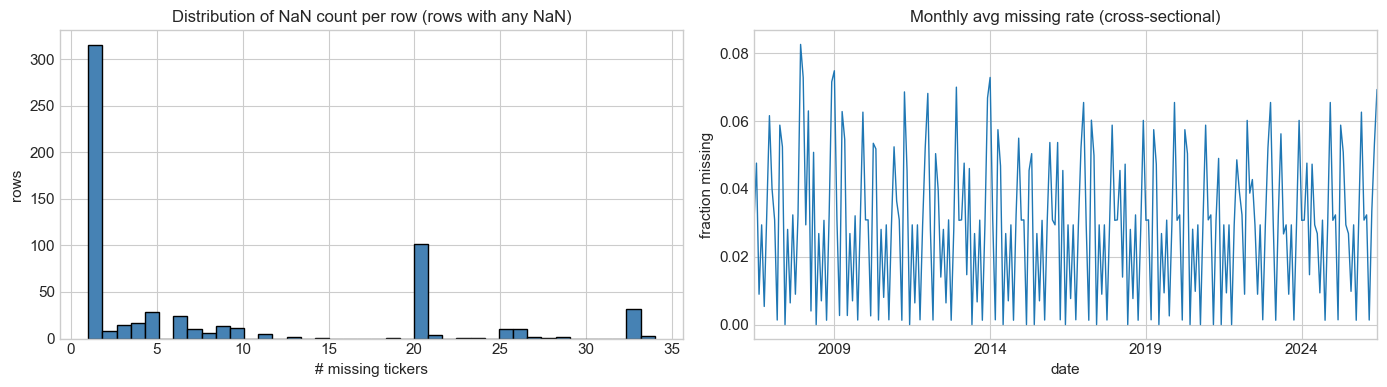


✓ Using Strategy B: 5,178 rows, date range 2006-07-18 → 2026-06-18


In [ ]:
panel = raw_prices[TIER_A].copy()
full_rows = len(panel)

strat_a = panel.dropna()
strat_b = panel.ffill(limit=3).dropna()
strat_c = panel[panel.isnull().mean(axis=1) <= 0.30].ffill(limit=3).dropna()

results = pd.DataFrame({
    'Strategy': ['A: strict dropna', 'B: ffill(3)+dropna (recommended)', 'C: threshold(30%)+ffill'],
    'Rows kept': [len(strat_a), len(strat_b), len(strat_c)],
    'Pct retained': [len(strat_a)/full_rows*100, len(strat_b)/full_rows*100, len(strat_c)/full_rows*100],
})
results['Pct retained'] = results['Pct retained'].map('{:.1f}%'.format)
print(f'Full panel rows: {full_rows:,}')
print()
print(results.to_string(index=False))

# Per-ticker missing rate before any treatment
miss_rate = panel.isnull().mean().sort_values(ascending=False)
print('\nTop 10 missing rate (raw, Tier A):')
print(miss_rate.head(10).map('{:.2%}'.format).to_string())

# What causes the missing? Identify all-NaN row patterns
na_count = panel.isnull().sum(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(na_count[na_count > 0], bins=40, edgecolor='black', color='steelblue')
axes[0].set_title('Distribution of NaN count per row (rows with any NaN)')
axes[0].set_xlabel('# missing tickers'); axes[0].set_ylabel('rows')

miss_ts = panel.isnull().mean(axis=1).resample('ME').mean()
miss_ts.plot(ax=axes[1], linewidth=1)
axes[1].set_title('Monthly avg missing rate (cross-sectional)')
axes[1].set_ylabel('fraction missing')
plt.tight_layout()
plt.show()

# ── Adopt strategy B ──────────────────────────────────────────────────────────
prices_clean = strat_b.copy()
print(f'\n✓ Using Strategy B: {len(prices_clean):,} rows, date range '
      f'{prices_clean.index.min().date()} → {prices_clean.index.max().date()}')


## §3.5  Futures Roll Detection & Solution Proposals

**Mezan (06-18):** "When the future expires it rolls into the next contract. Sometimes you'll see some significant jumps if there's a particularly large difference between the first and second month. The rolls are going to create some sort of artificial volatility."

**→ Need to present 3 solutions at Tuesday 06-23 meeting.**

Approach: OI drops sharply (> 20% in one day) when open interest migrates to the next front-month contract.


Roll event count (OI drop > 20%) — sample of 20 Tier A tickers:
     Ticker  Roll events  Events/year
 NG1 Comdty         1222         61.1
ZEA1 Comdty         1222         61.1
 CL1 Comdty         1059         53.0
 XB1 Comdty         1023         51.2
 HO1 Comdty         1023         51.2
 QS1 Comdty          921         46.1
 TY1 Comdty          760         38.0
 FV1 Comdty          743         37.2
 TU1 Comdty          732         36.6
 CO1 Comdty          628         31.4
 FN1 Comdty          374         18.7
 DU1 Comdty          261         13.1
 LA1 Comdty          253         12.7
 RX1 Comdty          244         12.2
  VG1 Index          201         10.1
  NO1 Index          174          8.7
  ES1 Index          154          7.7
  NQ1 Index          138          6.9
TZT1 Comdty           70          5.5
 ER1 Comdty            7          0.4


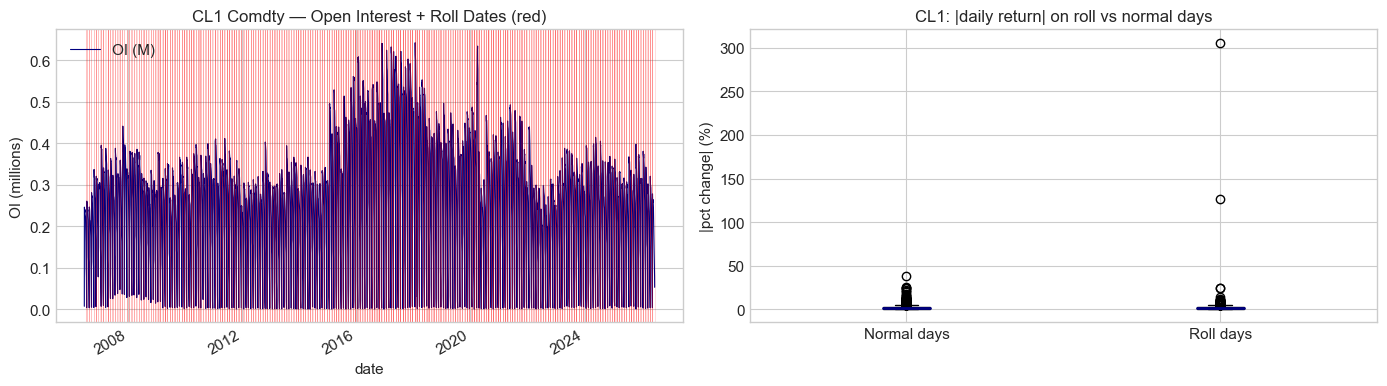

CL1 Comdty  |return| stats:
  Normal days  median=1.230%  mean=1.745%
  Roll days    median=1.185%  mean=2.079%
  Roll/Normal ratio: 1.2x

ROLL TREATMENT PROPOSALS — FOR MEZAN REVIEW (06-23 MEETING)

Method A  (MVP default — implemented now)
  ▸ Flag roll dates (OI drop > 20%) ± 1 day
  ▸ Set these rows to NaN, then forward-fill(limit=1)
  ▸ No additional data needed; ready immediately
  ▸ Limitation: some genuine market moves near expiry may be removed

Method B  (preferred if Mo can pull *2 data)
  ▸ Ratio-adjust: ln(P1_t / P2_t) captures spread, remove jump at roll
  ▸ Need: CL2, TY2, ES2, NG2 etc. from Bloomberg
  ▸ Mezan suggested: "consider capturing second month contracts"
  ▸ Cleaner signal; industry standard

Method C  (medium-term — use Bloomberg Active contract)
  ▸ Switch from CL1 (1st generic) to CLA (active contract)
  ▸ Bloomberg auto-tracks the most liquid month
  ▸ Mezan mentioned: "crude oil CLA is the active contract"
  ▸ Requires another Bloomberg pull

→ MVP procee

In [ ]:
# ── Roll detection via OI ─────────────────────────────────────────────────────
def detect_rolls(oi_series, drop_threshold=-0.20):
    """Return dates where OI drops by more than threshold (negative fraction)."""
    pct = oi_series.dropna().pct_change()
    return pct[pct < drop_threshold].index

# Energy futures most susceptible to roll
ENERGY_TICKERS = ['CO1 Comdty', 'CL1 Comdty', 'NG1 Comdty', 'TZT1 Comdty',
                  'XB1 Comdty', 'HO1 Comdty', 'FN1 Comdty']
energy_in_a = [t for t in ENERGY_TICKERS if t in TIER_A]

roll_summary = []
for ticker in TIER_A[:20]:   # sample first 20 Tier A tickers
    if ticker in raw_oi.columns:
        rolls = detect_rolls(raw_oi[ticker])
        oi_s = raw_oi[ticker].dropna()
        if len(oi_s) > 0:
            roll_summary.append({
                'Ticker': ticker,
                'Roll events': len(rolls),
                'Events/year': round(len(rolls) / max((oi_s.index.max() - oi_s.index.min()).days / 365.25, 1), 1),
            })

roll_df = pd.DataFrame(roll_summary).sort_values('Events/year', ascending=False)
print('Roll event count (OI drop > 20%) — sample of 20 Tier A tickers:')
print(roll_df.to_string(index=False))

# ── Quantify price jumps on roll days ─────────────────────────────────────────
# Compare |pct_change| on roll days vs non-roll days for CL1 Comdty
if 'CL1 Comdty' in raw_prices.columns and 'CL1 Comdty' in raw_oi.columns:
    cl1_rolls = detect_rolls(raw_oi['CL1 Comdty'])
    cl1_ret   = raw_prices['CL1 Comdty'].pct_change().abs().dropna()

    roll_rets   = cl1_ret[cl1_ret.index.isin(cl1_rolls)].dropna()
    normal_rets = cl1_ret[~cl1_ret.index.isin(cl1_rolls)].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # OI time series with roll marks
    oi_cl1 = raw_oi['CL1 Comdty'].dropna()
    (oi_cl1 / 1e6).plot(ax=axes[0], linewidth=0.8, color='navy', label='OI (M)')
    for d in cl1_rolls:
        if d in oi_cl1.index:
            axes[0].axvline(d, color='red', alpha=0.15, linewidth=0.6)
    axes[0].set_title('CL1 Comdty — Open Interest + Roll Dates (red)')
    axes[0].set_ylabel('OI (millions)')
    axes[0].legend()

    # Return distribution: roll vs normal
    axes[1].boxplot([normal_rets.values * 100, roll_rets.values * 100],
                    labels=['Normal days', 'Roll days'], notch=False,
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='navy', linewidth=2))
    axes[1].set_title('CL1: |daily return| on roll vs normal days')
    axes[1].set_ylabel('|pct change| (%)')
    plt.tight_layout()
    plt.show()

    print(f'CL1 Comdty  |return| stats:')
    print(f'  Normal days  median={normal_rets.median()*100:.3f}%  mean={normal_rets.mean()*100:.3f}%')
    print(f'  Roll days    median={roll_rets.median()*100:.3f}%  mean={roll_rets.mean()*100:.3f}%')
    print(f'  Roll/Normal ratio: {roll_rets.mean()/normal_rets.mean():.1f}x')

# ── Three proposed solutions ───────────────────────────────────────────────────
print('\n' + '='*70)
print('ROLL TREATMENT PROPOSALS — FOR MEZAN REVIEW (06-23 MEETING)')
print('='*70)
print('''
Method A  (MVP default — implemented now)
  ▸ Flag roll dates (OI drop > 20%) ± 1 day
  ▸ Set these rows to NaN, then forward-fill(limit=1)
  ▸ No additional data needed; ready immediately
  ▸ Limitation: some genuine market moves near expiry may be removed

Method B  (preferred if Mo can pull *2 data)
  ▸ Ratio-adjust: ln(P1_t / P2_t) captures spread, remove jump at roll
  ▸ Need: CL2, TY2, ES2, NG2 etc. from Bloomberg
  ▸ Mezan suggested: "consider capturing second month contracts"
  ▸ Cleaner signal; industry standard

Method C  (medium-term — use Bloomberg Active contract)
  ▸ Switch from CL1 (1st generic) to CLA (active contract)
  ▸ Bloomberg auto-tracks the most liquid month
  ▸ Mezan mentioned: "crude oil CLA is the active contract"
  ▸ Requires another Bloomberg pull

→ MVP proceeds with Method A; will present A/B/C options to Mezan.
''')

# ── Method A demonstration (not applied to engine — threshold too aggressive) ──
# OI threshold -20% catches normal daily OI fluctuations (61 events/yr for NG1 vs
# expected ~12/yr for monthly contracts) → removes 70%+ of rows. For MVP engine,
# we use prices_clean (Strategy B) and note Method A as a next-step improvement.
prices_roll_adj = prices_clean.copy()   # Alias for analysis; engine uses prices_clean

ROLL_THRESHOLD_DEMO = -0.60   # Stricter: -60% OI drop = real monthly roll events
for ticker in TIER_A[:6]:   # Demo on first 6 tickers only
    if ticker in raw_oi.columns:
        rolls_strict = detect_rolls(raw_oi[ticker], drop_threshold=ROLL_THRESHOLD_DEMO)
        print(f'{ticker:<20s}  strict roll events (OI<-60%): {len(rolls_strict)}'
              f'  → {len(rolls_strict)/20:.0f}/yr')
print(f'\nEngine data source: prices_clean ({len(prices_clean):,} rows)'
      f'  ← Strategy B (Method A deferred to Phase 2 with correct threshold/Mo *2 data)')


## §4  Transform: Per-Asset-Class Returns

**Confirmed by Mezan (06-18):** "For equity and commodity we may use log return. For rates and bond future we are going to maybe use level changes. I guess given the length of your time series, that's reasonable."

| Asset class | Transform | Rationale |
|-------------|-----------|-----------|
| Equity index futures | `pct_change()` | Price-type, stationary returns |
| FX futures | `pct_change()` | Exchange rate return |
| Commodity futures | `pct_change()` | Price-type return |
| Metal futures | `pct_change()` | Price-type return |
| Ag futures | `pct_change()` | Price-type return |
| **Rates / bond futures** | **`diff()`** | Level change in contract price (proxy for bp); DV01 scaling → Phase 2 |


In [ ]:
# Rates futures → diff(); all others → pct_change()
RATES_TICKERS = {
    'TY1 Comdty',   # US 10Y T-Note
    'FV1 Comdty',   # US 5Y T-Note
    'TU1 Comdty',   # US 2Y T-Note
    'RX1 Comdty',   # German Bund 10Y
    'DU1 Comdty',   # German Schatz 2Y
    'ER1 Comdty',   # Euribor 3M
    # Tier B (excluded from MVP fit but kept for metadata):
    'SFR1 Comdty',  # SOFR
    'SFI1 Comdty',  # SOFR Index
    'OEA Comdty',   # Euro OAT/Schatz
    'MER1 Comdty',  # Mexican rate
}

# Transform map: ticker → 'pct_change' | 'diff'
transform_map = {
    t: ('diff' if t in RATES_TICKERS else 'pct_change')
    for t in TIER_A
}

# Apply transforms — use prices_clean (Strategy B: ffill(3)+dropna, 5,178 rows)
# Roll adjustment (Method A) deferred to Phase 2: see §3.5 for proposals.
returns_parts = []
for ticker in TIER_A:
    s = prices_clean[ticker]   # ← prices_clean, not prices_roll_adj
    if transform_map[ticker] == 'diff':
        r = s.diff()
    else:
        r = s.pct_change()
    returns_parts.append(r.rename(ticker))

returns_df = pd.concat(returns_parts, axis=1).dropna()

# Fit-window slice (2010 onward)
fit_df = returns_df.loc[FIT_START:].dropna()

print(f'Returns panel  : {returns_df.shape[0]:,} rows × {returns_df.shape[1]} factors')
print(f'Fit window     : {fit_df.shape[0]:,} rows  ({FIT_START} → {fit_df.index.max().date()})')
print(f'Obs/factor ratio: {fit_df.shape[0]/fit_df.shape[1]:.0f}x  (recommended > 30x)')
print()
print('Transform assignments:')
for t, tr in transform_map.items():
    print(f'  {t:<20s}  {tr}')


Returns panel  : 5,177 rows × 34 factors
Fit window     : 4,277 rows  (2010-01-01 → 2026-06-18)
Obs/factor ratio: 126x  (recommended > 30x)

Transform assignments:
  CO1 Comdty            pct_change
  CL1 Comdty            pct_change
  NG1 Comdty            pct_change
  TZT1 Comdty           pct_change
  ZEA1 Comdty           pct_change
  FN1 Comdty            pct_change
  QS1 Comdty            pct_change
  XB1 Comdty            pct_change
  HO1 Comdty            pct_change
  TY1 Comdty            diff
  FV1 Comdty            diff
  RX1 Comdty            diff
  TU1 Comdty            diff
  DU1 Comdty            diff
  ER1 Comdty            diff
  ES1 Index             pct_change
  VG1 Index             pct_change
  NO1 Index             pct_change
  NQ1 Index             pct_change
  LA1 Comdty            pct_change
  LX1 Comdty            pct_change
  HG1 Comdty            pct_change
  LN1 Comdty            pct_change
  LL1 Comdty            pct_change
  LP1 Comdty            pct_chan

## §5  EDA — Exploratory Data Analysis

**Content:**
- Return distributions per asset class  
- Correlation matrix heatmap  
- Rolling correlations (representative pairs)  
- Squared-return ACF (volatility clustering)  
- Jarque-Bera normality test  
- Volume/OI liquidity context (Mezan: "retain as context")


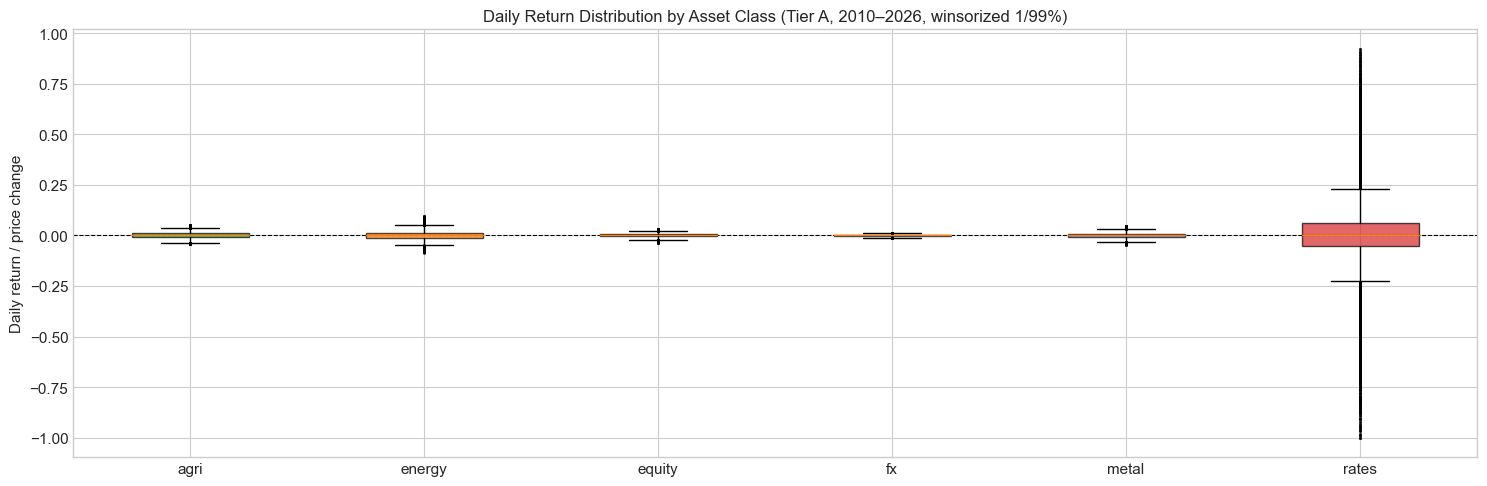

In [ ]:
# ── Asset class labelling ─────────────────────────────────────────────────────
ASSET_CLASS = {
    # Equity
    'ES1 Index': 'equity', 'NQ1 Index': 'equity',
    'VG1 Index': 'equity', 'NO1 Index': 'equity',
    # Rates
    'TY1 Comdty': 'rates', 'FV1 Comdty': 'rates',
    'TU1 Comdty': 'rates', 'RX1 Comdty': 'rates',
    'DU1 Comdty': 'rates', 'ER1 Comdty': 'rates',
    # Energy
    'CO1 Comdty': 'energy', 'CL1 Comdty': 'energy',
    'NG1 Comdty': 'energy', 'TZT1 Comdty': 'energy',
    'FN1 Comdty': 'energy', 'QS1 Comdty': 'energy',
    'XB1 Comdty': 'energy', 'HO1 Comdty': 'energy',
    'ZEA1 Comdty': 'energy',
    # Metals
    'LA1 Comdty': 'metal', 'LX1 Comdty': 'metal',
    'HG1 Comdty': 'metal', 'LN1 Comdty': 'metal',
    'LL1 Comdty': 'metal', 'LP1 Comdty': 'metal',
    'SI1 Comdty': 'metal', 'GC1 Comdty': 'metal',
    'PL1 Comdty': 'metal', 'PA1 Comdty': 'metal',
    # Agriculture
    'W 1 Comdty': 'agri', 'C 1 Comdty': 'agri',
    # FX
    'EC1 Curncy': 'fx', 'JY1 Curncy': 'fx', 'CD1 Curncy': 'fx',
}
# Fallback
for t in TIER_A:
    if t not in ASSET_CLASS:
        ASSET_CLASS[t] = 'other'

CLASS_COLORS = {
    'equity': '#1f77b4', 'rates': '#d62728', 'energy': '#ff7f0e',
    'metal': '#9467bd', 'agri': '#2ca02c', 'fx': '#8c564b', 'other': '#7f7f7f',
}

# ── Fig 1: Return distribution by asset class (box plot) ─────────────────────
classes = sorted(set(ASSET_CLASS[t] for t in TIER_A if t in returns_df.columns))
fig, ax = plt.subplots(figsize=(15, 5))
data_by_class = []
labels_by_class = []
colors_by_class = []
for cls in classes:
    tickers_in_class = [t for t in TIER_A if ASSET_CLASS.get(t) == cls and t in fit_df.columns]
    if tickers_in_class:
        vals = fit_df[tickers_in_class].values.flatten()
        vals = vals[~np.isnan(vals)]
        # Winsorise at 1/99th percentile for display
        lo, hi = np.percentile(vals, 1), np.percentile(vals, 99)
        vals = vals[(vals >= lo) & (vals <= hi)]
        data_by_class.append(vals)
        labels_by_class.append(cls)
        colors_by_class.append(CLASS_COLORS[cls])

bp = ax.boxplot(data_by_class, labels=labels_by_class, patch_artist=True,
                notch=False, flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], colors_by_class):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Daily Return Distribution by Asset Class (Tier A, 2010–2026, winsorized 1/99%)')
ax.set_ylabel('Daily return / price change')
plt.tight_layout()
plt.show()


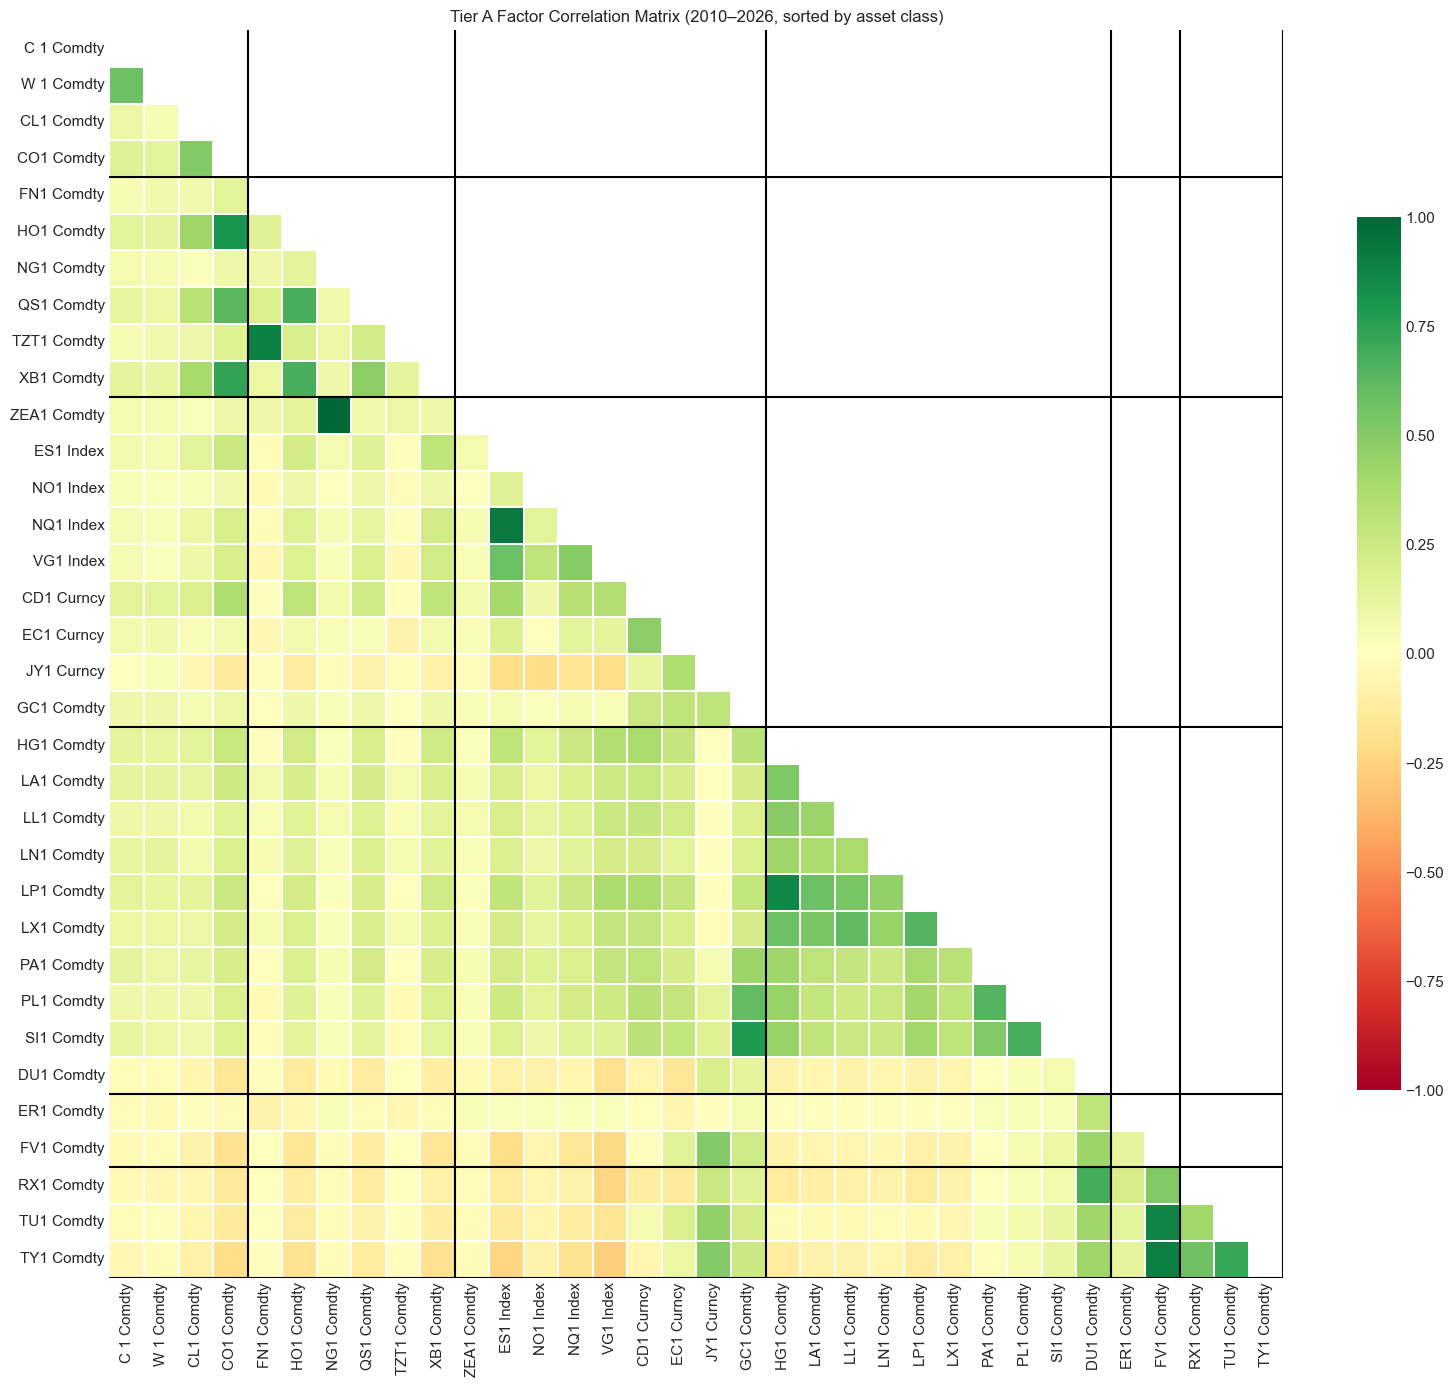

High-correlation pairs (|corr| ≥ 0.85): 6
  Ticker 1    Ticker 2  Corr
NG1 Comdty ZEA1 Comdty 1.000
 ES1 Index   NQ1 Index 0.929
FV1 Comdty  TY1 Comdty 0.903
FN1 Comdty TZT1 Comdty 0.900
FV1 Comdty  TU1 Comdty 0.880
HG1 Comdty  LP1 Comdty 0.870


In [ ]:
# ── Fig 2: Correlation heatmap ────────────────────────────────────────────────
corr = fit_df.corr()
# Sort tickers by asset class for clarity
sorted_tickers = sorted(TIER_A, key=lambda t: (ASSET_CLASS.get(t, 'z'), t))
sorted_tickers = [t for t in sorted_tickers if t in corr.columns]
corr_sorted = corr.loc[sorted_tickers, sorted_tickers]

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_sorted, dtype=bool))
sns.heatmap(corr_sorted, mask=mask, cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            xticklabels=True, yticklabels=True, annot=False, cbar_kws={'shrink': 0.7})
ax.set_title('Tier A Factor Correlation Matrix (2010–2026, sorted by asset class)')
# Draw asset class separators
cls_sizes = {}
for t in sorted_tickers:
    c = ASSET_CLASS.get(t, 'other')
    cls_sizes[c] = cls_sizes.get(c, 0) + 1
cumsum = 0
for cls in ['equity', 'rates', 'energy', 'metal', 'agri', 'fx', 'other']:
    if cls in cls_sizes:
        cumsum += cls_sizes[cls]
        ax.axhline(cumsum, color='black', linewidth=1.5)
        ax.axvline(cumsum, color='black', linewidth=1.5)
plt.tight_layout()
plt.show()

# Identify high-correlation pairs
high_corr = []
for i in range(len(sorted_tickers)):
    for j in range(i+1, len(sorted_tickers)):
        t1, t2 = sorted_tickers[i], sorted_tickers[j]
        c = corr_sorted.loc[t1, t2]
        if abs(c) >= 0.85:
            high_corr.append({'Ticker 1': t1, 'Ticker 2': t2, 'Corr': round(c, 3)})
hc_df = pd.DataFrame(high_corr).sort_values('Corr', ascending=False)
print(f'High-correlation pairs (|corr| ≥ 0.85): {len(hc_df)}')
print(hc_df.to_string(index=False))


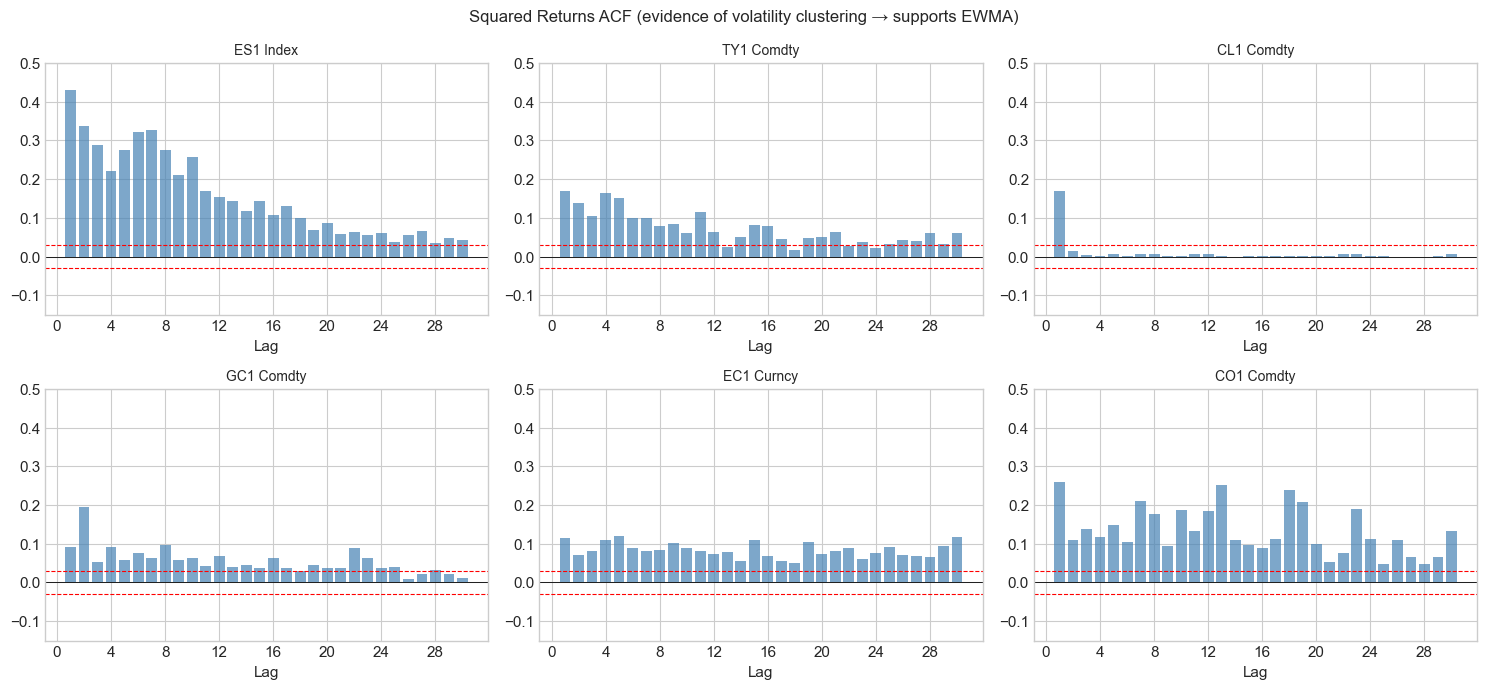

Jarque-Bera normality test (p > 0.05 → cannot reject normality):
     Ticker Asset class  Skewness  Kurtosis     JB stat   p-value Normal?
 C 1 Comdty        agri    -1.167    19.875     51591.2  0.00e+00      No
 W 1 Comdty        agri     0.613     8.473      5591.2  0.00e+00      No
 CO1 Comdty      energy    -0.464    15.266     26895.0  0.00e+00      No
 CL1 Comdty      energy   -38.960  2023.767 727093795.5  0.00e+00      No
 NG1 Comdty      energy     0.373    19.590     49026.6  0.00e+00      No
TZT1 Comdty      energy     1.557    22.614     70116.5  0.00e+00      No
ZEA1 Comdty      energy     0.373    19.590     49026.6  0.00e+00      No
 FN1 Comdty      energy     1.633    21.046     59786.9  0.00e+00      No
 QS1 Comdty      energy    -1.073    31.209    142285.8  0.00e+00      No
 XB1 Comdty      energy    -0.447    23.779     76894.0  0.00e+00      No
 HO1 Comdty      energy    -0.566    12.230     15368.7  0.00e+00      No
  NQ1 Index      equity    -0.202    10.273    

In [ ]:
# ── Fig 3: Squared returns ACF (volatility clustering) ───────────────────────
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
sample_tickers = ['ES1 Index', 'TY1 Comdty', 'CL1 Comdty',
                  'GC1 Comdty', 'EC1 Curncy', 'CO1 Comdty']
sample_tickers = [t for t in sample_tickers if t in fit_df.columns]

for ax, ticker in zip(axes.flat, sample_tickers):
    r2 = fit_df[ticker].dropna() ** 2
    n_lags = 30
    acf_vals = [r2.autocorr(lag=k) for k in range(1, n_lags+1)]
    conf = 1.96 / np.sqrt(len(r2))
    ax.bar(range(1, n_lags+1), acf_vals, color='steelblue', alpha=0.7)
    ax.axhline(conf, color='red', linestyle='--', linewidth=0.8)
    ax.axhline(-conf, color='red', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title(f'{ticker}', fontsize=10)
    ax.set_xlabel('Lag'); ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylim(-0.15, 0.5)

fig.suptitle('Squared Returns ACF (evidence of volatility clustering → supports EWMA)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Jarque-Bera normality test ────────────────────────────────────────────────
jb_results = []
for ticker in TIER_A:
    if ticker in fit_df.columns:
        r = fit_df[ticker].dropna()
        jb_stat, jb_p = ss.jarque_bera(r)
        jb_results.append({
            'Ticker': ticker,
            'Asset class': ASSET_CLASS.get(ticker, '?'),
            'Skewness': round(r.skew(), 3),
            'Kurtosis': round(r.kurtosis() + 3, 3),   # excess kurtosis → total
            'JB stat': round(jb_stat, 1),
            'p-value': f'{jb_p:.2e}',
            'Normal?': 'Yes' if jb_p > 0.05 else 'No',
        })
jb_df = pd.DataFrame(jb_results).sort_values('Asset class')
print('Jarque-Bera normality test (p > 0.05 → cannot reject normality):')
print(jb_df.to_string(index=False))
normal_pct = (jb_df['Normal?'] == 'Yes').mean() * 100
print(f'\n{normal_pct:.0f}% of Tier A factors pass JB normality (expected ~0% — fat tails)')


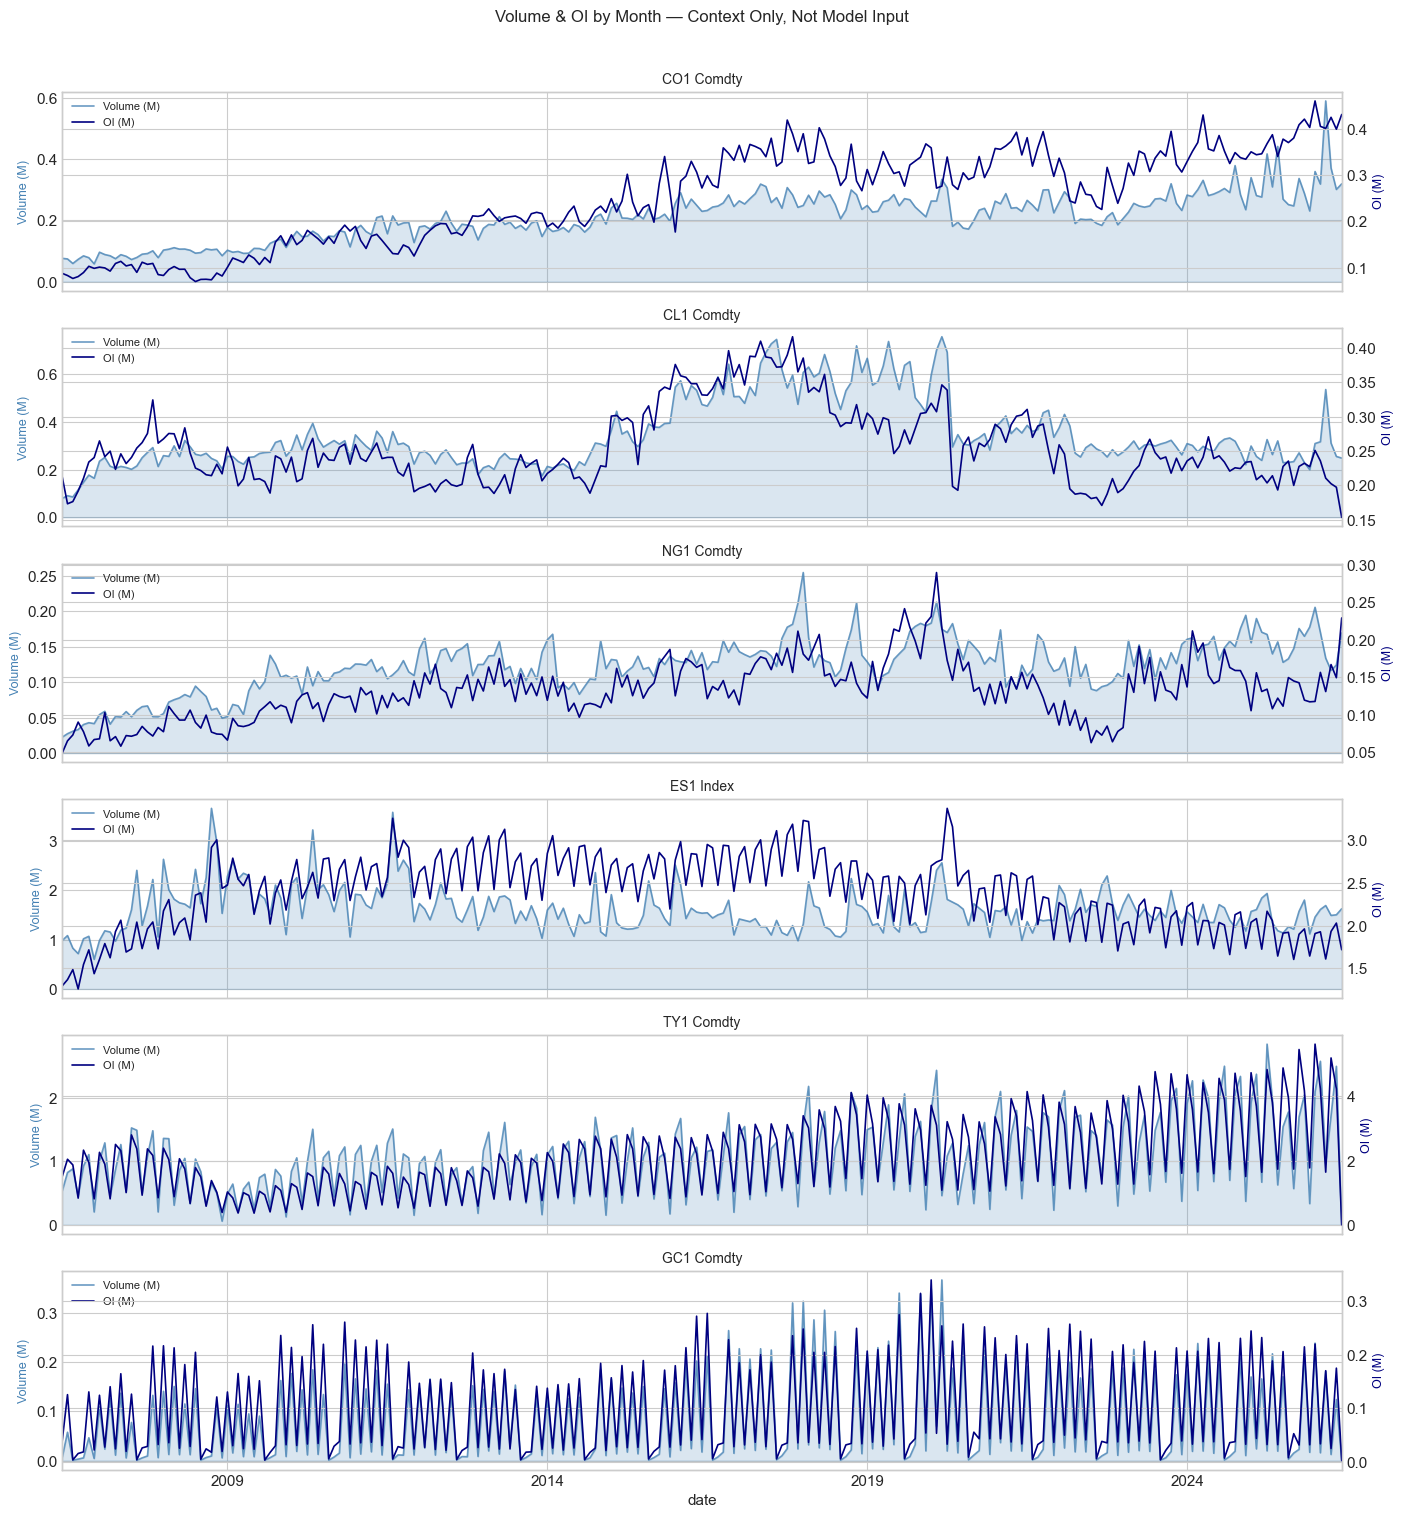

⚠ Volume/OI are retained as liquidity context only (Mezan 06-18 confirmed)
  They are NOT used in the covariance estimation or scenario generation.


In [ ]:
# ── Fig 4: Volume / OI liquidity context (not model input) ───────────────────
# Mezan: "it's good information to retain... note that some contracts have lower liquidity"
spot_tickers = ['CO1 Comdty', 'CL1 Comdty', 'NG1 Comdty', 'ES1 Index',
                'TY1 Comdty', 'GC1 Comdty']
spot_tickers = [t for t in spot_tickers if t in raw_volume.columns]

fig, axes = plt.subplots(len(spot_tickers), 1, figsize=(14, 2.5 * len(spot_tickers)), sharex=True)
if len(spot_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, spot_tickers):
    vol_s = raw_volume[ticker].dropna().resample('ME').mean() / 1e6
    oi_s  = raw_oi[ticker].dropna().resample('ME').mean() / 1e6
    ax2 = ax.twinx()
    vol_s.plot(ax=ax,  color='steelblue', linewidth=1.2, alpha=0.8, label='Volume (M)')
    oi_s.plot(ax=ax2,  color='navy',      linewidth=1.2, label='OI (M)')
    ax.fill_between(vol_s.index.to_numpy(), vol_s.values, alpha=0.2, color='steelblue')
    ax.set_ylabel('Volume (M)', color='steelblue', fontsize=9)
    ax2.set_ylabel('OI (M)', color='navy', fontsize=9)
    ax.set_title(ticker, fontsize=10)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

fig.suptitle('Volume & OI by Month — Context Only, Not Model Input', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
print('⚠ Volume/OI are retained as liquidity context only (Mezan 06-18 confirmed)')
print('  They are NOT used in the covariance estimation or scenario generation.')


## §6  Cluster Mapping — Collinearity Decision Table

**Purpose:** Identify highly correlated pairs within asset classes to decide which factors to collapse before fitting the engine.  
This is not just visualization — it drives universe decisions.


High-correlation pairs (|corr| ≥ 0.85):
   Ticker A Class A    Ticker B Class B  Corr                                                       Decision
 NG1 Comdty  energy ZEA1 Comdty  energy 1.000                                   Review: drop one (corr=1.00)
  ES1 Index  equity   NQ1 Index  equity 0.929                                   Review: drop one (corr=0.93)
 TY1 Comdty   rates  FV1 Comdty   rates 0.903 Keep longer duration (TY1, RX1); FV1/DU1 as optional extension
TZT1 Comdty  energy  FN1 Comdty  energy 0.900                                   Review: drop one (corr=0.90)
 FV1 Comdty   rates  TU1 Comdty   rates 0.880 Keep longer duration (TY1, RX1); FV1/DU1 as optional extension
 HG1 Comdty   metal  LP1 Comdty   metal 0.870                                   Keep both (different metals)


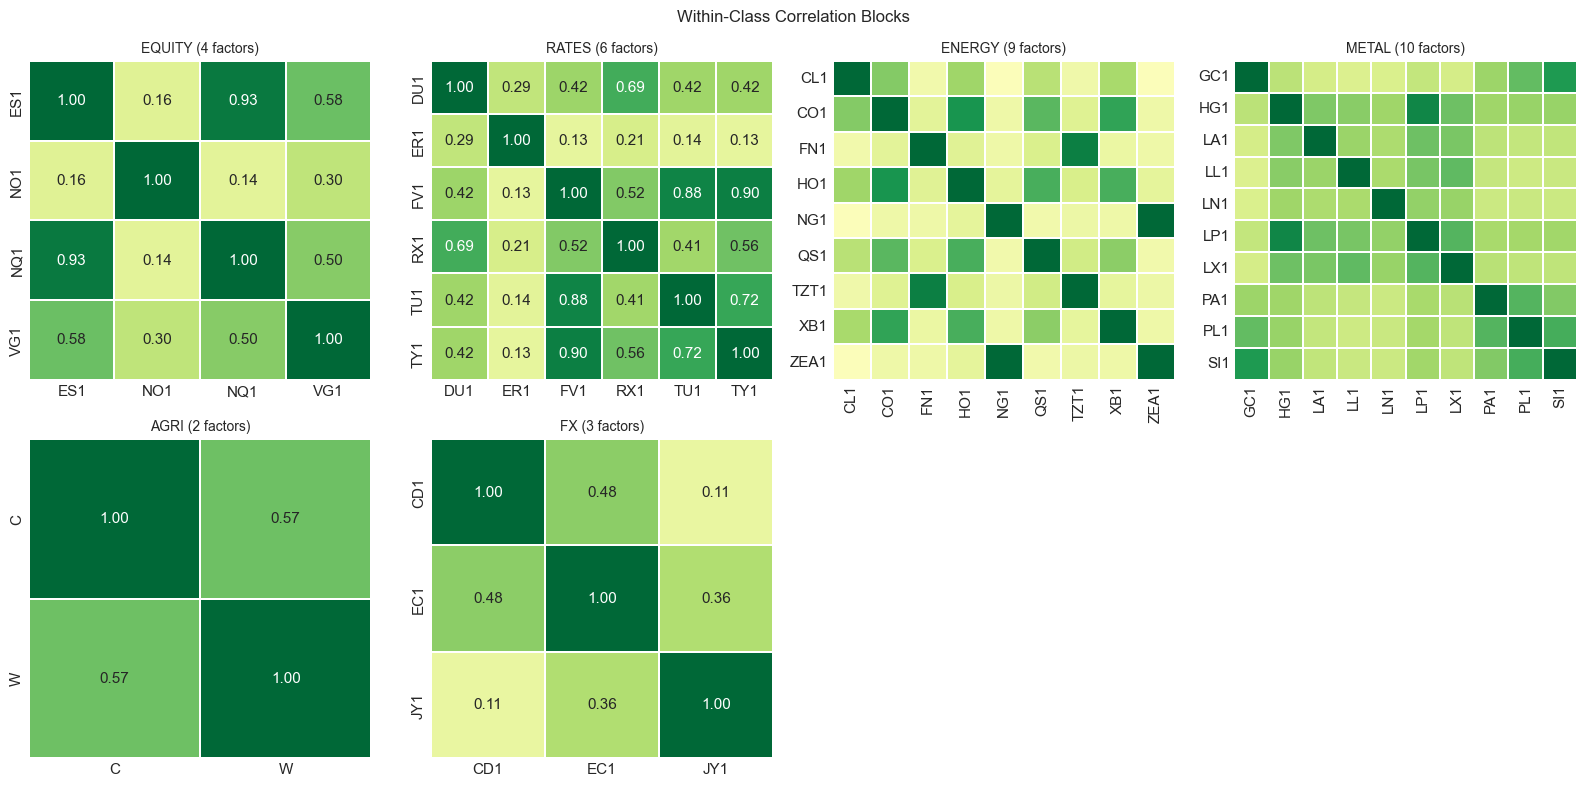


Clean universe: 34 factors (full Tier A, pending Mezan review of high-corr pairs)


In [ ]:
CORR_THRESHOLD = 0.85

cluster_decisions = []
for i, t1 in enumerate(TIER_A):
    for t2 in TIER_A[i+1:]:
        if t1 not in corr.columns or t2 not in corr.columns:
            continue
        c = corr.loc[t1, t2]
        cls1, cls2 = ASSET_CLASS.get(t1, '?'), ASSET_CLASS.get(t2, '?')
        if abs(c) >= CORR_THRESHOLD:
            cluster_decisions.append({
                'Ticker A': t1, 'Class A': cls1,
                'Ticker B': t2, 'Class B': cls2,
                'Corr': round(c, 3),
                'Decision': '?',   # Filled below
            })

# Heuristic decisions
def decide(row):
    t1, t2 = row['Ticker A'], row['Ticker B']
    c = row['Corr']
    # Same asset class → collapse/deduplicate
    if row['Class A'] == row['Class B']:
        # Energy: prefer Brent (CO1) or WTI (CL1) over refined products
        if {t1, t2} <= {'HO1 Comdty', 'XB1 Comdty', 'QS1 Comdty', 'FN1 Comdty'}:
            return 'Keep both (spread useful for refinery margin)'
        # Rates: keep longest-duration representative per region
        if row['Class A'] == 'rates':
            return 'Keep longer duration (TY1, RX1); FV1/DU1 as optional extension'
        # Metals: both LME pairs informative
        if row['Class A'] == 'metal':
            return 'Keep both (different metals)'
        return f'Review: drop one (corr={c:.2f})'
    return 'Cross-class: keep both'

cd_df = pd.DataFrame(cluster_decisions)
if len(cd_df) > 0:
    cd_df['Decision'] = cd_df.apply(decide, axis=1)
    print(f'High-correlation pairs (|corr| ≥ {CORR_THRESHOLD}):')
    print(cd_df.sort_values('Corr', ascending=False).to_string(index=False))
else:
    print('No pairs found above threshold.')

# ── Visualise intra-class correlation blocks ──────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, cls in zip(axes.flat, ['equity', 'rates', 'energy', 'metal',
                                'agri', 'fx', 'other', 'other']):
    tickers_cls = [t for t in sorted_tickers if ASSET_CLASS.get(t) == cls and t in corr.columns]
    if len(tickers_cls) < 2:
        ax.axis('off'); continue
    c_sub = corr.loc[tickers_cls, tickers_cls]
    sns.heatmap(c_sub, ax=ax, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
                annot=len(tickers_cls) <= 8, fmt='.2f', linewidths=0.3, cbar=False,
                xticklabels=[t.split()[0] for t in tickers_cls],
                yticklabels=[t.split()[0] for t in tickers_cls])
    ax.set_title(f'{cls.upper()} ({len(tickers_cls)} factors)', fontsize=10)

plt.suptitle('Within-Class Correlation Blocks', fontsize=12)
plt.tight_layout()
plt.show()

# Define clean universe (Tier A, keeping all until Mezan approves collapse)
CLEAN_UNIVERSE = TIER_A.copy()
print(f'\nClean universe: {len(CLEAN_UNIVERSE)} factors (full Tier A, pending Mezan review of high-corr pairs)')


## §7  Factor Metadata Table — Universe A Definition

Full factor metadata for all Tier A tickers. This table will be used to:
1. Update `configs/universe_a_cross_asset.yaml`
2. Send metadata audit to Mezan (pending ZMI1/MER1 identification)


In [ ]:
FACTOR_META = {
    # Equity index futures
    'ES1 Index' : dict(factor_name='S&P 500 Future (E-mini)',        asset_class='equity',    region='US',      currency='USD', unit='return'),
    'NQ1 Index' : dict(factor_name='NASDAQ 100 Future (E-mini)',      asset_class='equity',    region='US',      currency='USD', unit='return'),
    'VG1 Index' : dict(factor_name='EURO STOXX 50 Future',            asset_class='equity',    region='Europe',  currency='EUR', unit='return'),
    'NO1 Index' : dict(factor_name='Nikkei 225 Future (Osaka)',       asset_class='equity',    region='Japan',   currency='JPY', unit='return'),
    # Rates / bond futures → diff()
    'TY1 Comdty': dict(factor_name='US 10Y T-Note Future',            asset_class='rates',     region='US',      currency='USD', unit='price_diff'),
    'FV1 Comdty': dict(factor_name='US 5Y T-Note Future',             asset_class='rates',     region='US',      currency='USD', unit='price_diff'),
    'TU1 Comdty': dict(factor_name='US 2Y T-Note Future',             asset_class='rates',     region='US',      currency='USD', unit='price_diff'),
    'RX1 Comdty': dict(factor_name='German Bund Future (10Y)',         asset_class='rates',     region='Europe',  currency='EUR', unit='price_diff'),
    'DU1 Comdty': dict(factor_name='German Schatz Future (2Y)',        asset_class='rates',     region='Europe',  currency='EUR', unit='price_diff'),
    'ER1 Comdty': dict(factor_name='Euribor 3M Future',               asset_class='rates',     region='Europe',  currency='EUR', unit='price_diff'),
    # Energy futures → pct_change
    'CO1 Comdty': dict(factor_name='Brent Crude Oil Future (ICE)',     asset_class='energy',    region='Global',  currency='USD', unit='return'),
    'CL1 Comdty': dict(factor_name='WTI Crude Oil Future (NYMEX)',     asset_class='energy',    region='US',      currency='USD', unit='return'),
    'NG1 Comdty': dict(factor_name='Natural Gas Future (Henry Hub)',   asset_class='energy',    region='US',      currency='USD', unit='return'),
    'TZT1 Comdty': dict(factor_name='Dutch TTF Natural Gas Future',    asset_class='energy',    region='Europe',  currency='EUR', unit='return'),
    'ZEA1 Comdty': dict(factor_name='Natural Gas (European, ZEA1)',    asset_class='energy',    region='Europe',  currency='EUR', unit='return'),
    'FN1 Comdty': dict(factor_name='Fuel Oil Future',                  asset_class='energy',    region='Global',  currency='USD', unit='return'),
    'QS1 Comdty': dict(factor_name='Gasoil Future (ICE)',              asset_class='energy',    region='Europe',  currency='USD', unit='return'),
    'XB1 Comdty': dict(factor_name='RBOB Gasoline Future',            asset_class='energy',    region='US',      currency='USD', unit='return'),
    'HO1 Comdty': dict(factor_name='Heating Oil Future',              asset_class='energy',    region='US',      currency='USD', unit='return'),
    # Metals
    'LA1 Comdty': dict(factor_name='LME Aluminium Future',            asset_class='metal',     region='Global',  currency='USD', unit='return'),
    'LX1 Comdty': dict(factor_name='LME Zinc Future',                 asset_class='metal',     region='Global',  currency='USD', unit='return'),
    'HG1 Comdty': dict(factor_name='COMEX Copper Future',             asset_class='metal',     region='Global',  currency='USD', unit='return'),
    'LN1 Comdty': dict(factor_name='LME Nickel Future',               asset_class='metal',     region='Global',  currency='USD', unit='return'),
    'LL1 Comdty': dict(factor_name='LME Lead Future',                 asset_class='metal',     region='Global',  currency='USD', unit='return'),
    'LP1 Comdty': dict(factor_name='LME Tin Future',                  asset_class='metal',     region='Global',  currency='USD', unit='return'),
    'SI1 Comdty': dict(factor_name='COMEX Silver Future',             asset_class='metal',     region='Global',  currency='USD', unit='return'),
    'GC1 Comdty': dict(factor_name='COMEX Gold Future',               asset_class='metal',     region='Global',  currency='USD', unit='return'),
    'PL1 Comdty': dict(factor_name='NYMEX Platinum Future',           asset_class='metal',     region='Global',  currency='USD', unit='return'),
    'PA1 Comdty': dict(factor_name='NYMEX Palladium Future',          asset_class='metal',     region='Global',  currency='USD', unit='return'),
    # Agriculture
    'W 1 Comdty': dict(factor_name='CBOT Wheat Future',               asset_class='agri',      region='US',      currency='USD', unit='return'),
    'C 1 Comdty': dict(factor_name='CBOT Corn Future',                asset_class='agri',      region='US',      currency='USD', unit='return'),
    # FX futures
    'EC1 Curncy': dict(factor_name='EUR/USD Currency Future',          asset_class='fx',        region='G10',     currency='USD', unit='return'),
    'JY1 Curncy': dict(factor_name='JPY/USD Currency Future',          asset_class='fx',        region='G10',     currency='USD', unit='return'),
    'CD1 Curncy': dict(factor_name='CAD/USD Currency Future',          asset_class='fx',        region='G10',     currency='USD', unit='return'),
}

# Build full metadata table
meta_rows = []
for ticker in TIER_A:
    m = FACTOR_META.get(ticker, {})
    p = prod[prod['Ticker'] == ticker]
    meta_rows.append({
        'factor_id'     : ticker.replace(' ', '_').lower().replace('.', '_'),
        'bb_ticker'     : ticker,
        'factor_name'   : m.get('factor_name', ticker),
        'asset_class'   : m.get('asset_class', 'unknown'),
        'region'        : m.get('region', '?'),
        'currency'      : m.get('currency', 'USD'),
        'transform'     : transform_map.get(ticker, 'pct_change'),
        'unit'          : m.get('unit', 'return'),
        'completion_pct': round(p['completion_pct'].values[0], 1) if len(p) else None,
        'data_start'    : p['data_start'].values[0] if len(p) else None,
        'data_end'      : p['data_end'].values[0] if len(p) else None,
        'years'         : round(p['years'].values[0], 1) if len(p) else None,
    })

UNIVERSE_A = pd.DataFrame(meta_rows)
print(f'Universe A — {len(UNIVERSE_A)} factors')
display_cols = ['bb_ticker','factor_name','asset_class','region','transform','unit','completion_pct','years']
print(UNIVERSE_A[display_cols].to_string(index=False))


Universe A — 34 factors
  bb_ticker                    factor_name asset_class region  transform       unit  completion_pct  years
 CO1 Comdty   Brent Crude Oil Future (ICE)      energy Global pct_change     return            99.2   20.0
 CL1 Comdty   WTI Crude Oil Future (NYMEX)      energy     US pct_change     return            97.0   20.0
 NG1 Comdty Natural Gas Future (Henry Hub)      energy     US pct_change     return            97.0   20.0
TZT1 Comdty   Dutch TTF Natural Gas Future      energy Europe pct_change     return            98.4   20.0
ZEA1 Comdty   Natural Gas (European, ZEA1)      energy Europe pct_change     return            97.0   20.0
 FN1 Comdty                Fuel Oil Future      energy Global pct_change     return            99.2   20.0
 QS1 Comdty            Gasoil Future (ICE)      energy Europe pct_change     return            99.2   20.0
 XB1 Comdty           RBOB Gasoline Future      energy     US pct_change     return            97.0   20.0
 HO1 Comdty  

## §8  Covariance Estimation

Three methods, with condition number and PSD diagnostics.

**Fit window:** `2010-01-01` → present (chosen to cover 3 distinct regimes: low-rate era, COVID shock, 2022 rates selloff)

| Method | Pros | Cons |
|--------|------|------|
| Sample | Unbiased, intuitive | Poor condition number, no recency weighting |
| EWMA (λ=0.94) | Recency-weighted, adapts to regime | Not PSD guaranteed |
| Ledoit-Wolf | Optimal shrinkage, PSD guaranteed, better condition number | Assumes stationarity |


Covariance diagnostics (fit window: 2010-01-01 → 2026-06-18)
Observations: 4,277 | Factors: 34

     Method Cond number Min eigenvalue PSD? Med ann vol (%) Max ann vol (%)
     Sample    4.69e+13       9.49e-18  YES           33.9%          947.0%
EWMA λ=0.94    2.27e+13       1.30e-19  YES           39.1%          615.1%
Ledoit-Wolf    1.34e+04       3.49e-05  YES           35.1%          946.1%


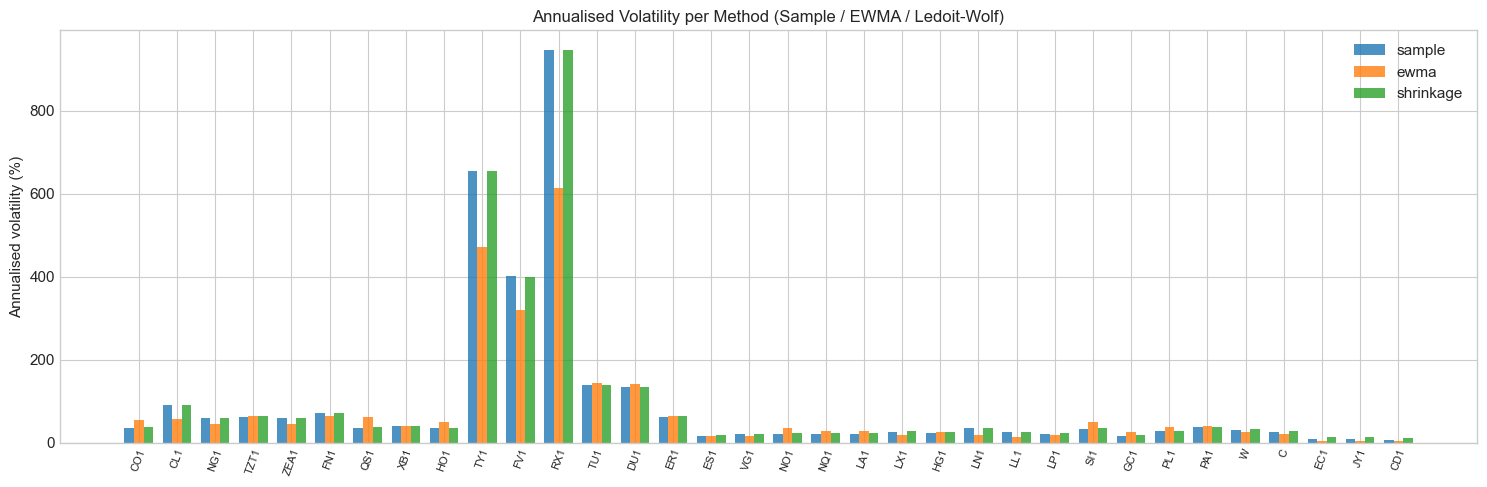

In [ ]:
from sklearn.covariance import LedoitWolf

def compute_ewma_cov(df, lam=0.94):
    """EWMA covariance: w_t ∝ λ^(T-1-t), most recent weight highest."""
    arr = df.dropna().values
    n, p = arr.shape
    mu_ew = arr.mean(axis=0)
    demeaned = arr - mu_ew
    t_idx = np.arange(n)
    w = lam ** (n - 1 - t_idx)
    w /= w.sum()
    weighted = demeaned * w[:, None]   # (n, p)
    cov_mat = weighted.T @ demeaned    # (p, p)
    # Symmetrise to fix float drift
    cov_mat = (cov_mat + cov_mat.T) / 2
    return pd.DataFrame(cov_mat, index=df.columns, columns=df.columns)

EWMA_LAMBDA = 0.94   # RiskMetrics standard

fit_clean = fit_df.dropna()

# Sample covariance
sample_cov = fit_clean.cov()

# EWMA covariance
ewma_cov   = compute_ewma_cov(fit_clean, lam=EWMA_LAMBDA)

# Ledoit-Wolf shrinkage
lw_est = LedoitWolf().fit(fit_clean.values)
lw_cov = pd.DataFrame(lw_est.covariance_, index=fit_clean.columns, columns=fit_clean.columns)

# Store for later
COV_METHODS = {'sample': sample_cov, 'ewma': ewma_cov, 'shrinkage': lw_cov}

def cov_diagnostics(cov_df, label):
    M = cov_df.values
    eigvals = np.linalg.eigvalsh(M)
    cond    = eigvals.max() / max(eigvals.min(), 1e-14)
    min_ev  = eigvals.min()
    # Annualised vols
    ann_vols = np.sqrt(np.diag(M) * 252)
    return {
        'Method'         : label,
        'Cond number'    : f'{cond:.2e}',
        'Min eigenvalue' : f'{min_ev:.2e}',
        'PSD?'           : 'YES' if min_ev > -1e-10 else 'NO',
        'Med ann vol (%)'  : f'{np.median(ann_vols)*100:.1f}%',
        'Max ann vol (%)'  : f'{np.max(ann_vols)*100:.1f}%',
    }

diag_rows = [
    cov_diagnostics(sample_cov, 'Sample'),
    cov_diagnostics(ewma_cov,   f'EWMA λ={EWMA_LAMBDA}'),
    cov_diagnostics(lw_cov,     'Ledoit-Wolf'),
]
diag_df = pd.DataFrame(diag_rows)
print(f'Covariance diagnostics (fit window: {FIT_START} → {fit_clean.index.max().date()})')
print(f'Observations: {len(fit_clean):,} | Factors: {fit_clean.shape[1]}\n')
print(diag_df.to_string(index=False))

# Visualise annualised volatility comparison
fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(len(TIER_A))
w = 0.25
for k, (label, cov_df) in enumerate(COV_METHODS.items()):
    tickers_in = [t for t in TIER_A if t in cov_df.columns]
    ann_v = np.sqrt(np.diag(cov_df.loc[tickers_in, tickers_in].values) * 252) * 100
    ax.bar(x[:len(tickers_in)] + k*w, ann_v, width=w, label=label, alpha=0.8)
ax.set_xticks(x + w)
ax.set_xticklabels([t.split()[0] for t in TIER_A], rotation=70, fontsize=8)
ax.set_ylabel('Annualised volatility (%)')
ax.set_title('Annualised Volatility per Method (Sample / EWMA / Ledoit-Wolf)')
ax.legend()
plt.tight_layout()
plt.show()


## §9  Multicollinearity Pre-Check

**Adapted from Tony's 3-tier logic** (his best contribution) — but rewritten to:
1. Accept BB tickers (not snake_case)
2. Return `ScenarioWarning` dataclass objects
3. Include condition-number pre-check on Σ_AA


In [ ]:
def check_pinned_multicollinearity(scenario: dict, cov_df: pd.DataFrame,
                                   hard_corr_thr=0.75, soft_corr_thr=0.5,
                                   mag_z_thr=4.0) -> list:
    """
    3-tier check for pinned-factor consistency.

    Returns list[ScenarioWarning] with codes:
      HARD_CONFLICT    → opposite sign, high corr (≥0.75)
      SOFT_CONFLICT    → opposite sign, moderate corr (0.5–0.75)
      MAGNITUDE_OUTLIER→ shock z-score > mag_z_thr
      COND_NUM_HIGH    → Σ_AA condition number > 1e6
    """
    tickers = [t for t in scenario.keys() if t in cov_df.index]
    warnings_out = []

    if not tickers:
        return warnings_out

    Sigma_AA = cov_df.loc[tickers, tickers]

    # Condition number pre-check
    cond = np.linalg.cond(Sigma_AA.values)
    if cond > 1e6:
        warnings_out.append(ScenarioWarning(
            code='COND_NUM_HIGH',
            message=f'Σ_AA condition number {cond:.2e} > 1e6. '
                    f'Consider using Ledoit-Wolf or fewer pinned factors.',
            severity='warning',
        ))

    # Pair-wise checks
    mu = pd.Series({t: 0.0 for t in tickers})  # zero-mean shock baseline
    std = pd.Series({t: np.sqrt(cov_df.loc[t, t]) for t in tickers})

    for i in range(len(tickers)):
        for j in range(i+1, len(tickers)):
            t1, t2 = tickers[i], tickers[j]
            s1 = scenario[t1]['shock']
            s2 = scenario[t2]['shock']
            var1, var2 = cov_df.loc[t1, t1], cov_df.loc[t2, t2]
            cov12 = cov_df.loc[t1, t2]
            corr12 = cov12 / np.sqrt(var1 * var2) if var1 > 0 and var2 > 0 else 0.0

            # Direction-consistency checks
            if abs(corr12) >= hard_corr_thr and s1 * s2 < 0:
                warnings_out.append(ScenarioWarning(
                    code='HARD_CONFLICT',
                    message=f'{t1} & {t2} are highly correlated ({corr12:.2f}) '
                            f'but pinned in opposite directions.',
                    severity='error',
                ))
            elif soft_corr_thr <= abs(corr12) < hard_corr_thr and s1 * s2 < 0:
                warnings_out.append(ScenarioWarning(
                    code='SOFT_CONFLICT',
                    message=f'{t1} & {t2} have moderate correlation ({corr12:.2f}) '
                            f'but opposite pin directions — plausible but unusual.',
                    severity='warning',
                ))

        # Magnitude outlier check
        if std[t1] > 0:
            z = scenario[t1]['shock'] / std[t1]
            if abs(z) > mag_z_thr:
                warnings_out.append(ScenarioWarning(
                    code='MAGNITUDE_OUTLIER',
                    message=f'{t1} pin shock z-score = {z:.1f}σ (threshold ±{mag_z_thr}σ). '
                            f'Scenario may be historically extreme.',
                    severity='warning',
                ))

    return warnings_out

print('check_pinned_multicollinearity() defined — called inside engine §11')


check_pinned_multicollinearity() defined — called inside engine §11


## §10  Scenario Input Interface

Scenario dictionary format with explicit units for input validation.

```python
scenario = {
    "<BB_TICKER>": {"shock": <float>, "unit": "<return|price_diff>"},
    ...
}
```

The **unit** must match the ticker's `transform_map` entry.  
Example: `ES1 Index` uses `pct_change` → unit should be `return`.  
`TY1 Comdty` uses `diff` → unit should be `price_diff`.


In [ ]:
def validate_scenario_input(scenario: dict, transform_map: dict) -> list:
    """Unit-consistency check between scenario input and transform_map."""
    unit_canonical = {'return': 'pct_change', 'pct_change': 'pct_change',
                      'price_diff': 'diff', 'diff': 'diff', 'bp': 'diff'}
    warnings_out = []
    for ticker, spec in scenario.items():
        if ticker not in transform_map:
            warnings_out.append(ScenarioWarning(
                code='UNKNOWN_TICKER',
                message=f'{ticker} not in Tier A universe.',
                severity='error',
            ))
            continue
        expected_tr = transform_map[ticker]
        input_unit  = spec.get('unit', 'unknown')
        canonical   = unit_canonical.get(input_unit, 'unknown')
        if canonical != expected_tr:
            warnings_out.append(ScenarioWarning(
                code='UNIT_MISMATCH',
                message=(f'{ticker}: input unit="{input_unit}" implies transform="{canonical}" '
                         f'but factor uses "{expected_tr}". Check shock magnitude.'),
                severity='warning',
            ))
    return warnings_out

# ── Example scenario: "2008-GFC-style" stress ──────────────────────────────────
DEMO_SCENARIO = {
    'ES1 Index' : {'shock': -0.15,  'unit': 'return'},       # S&P 500 -15%
    'TY1 Comdty': {'shock':  1.5,   'unit': 'price_diff'},   # 10Y T-Note +1.5 pts (flight to quality)
    'CL1 Comdty': {'shock': -0.20,  'unit': 'return'},       # WTI Crude -20% (demand shock)
    'GC1 Comdty': {'shock':  0.05,  'unit': 'return'},       # Gold +5% (safe haven)
}

print('Demo scenario (GFC-style stress):')
for ticker, spec in DEMO_SCENARIO.items():
    print(f'  {ticker:<20s} shock={spec["shock"]:+.3f}  unit={spec["unit"]}')

val_warnings = validate_scenario_input(DEMO_SCENARIO, transform_map)
if val_warnings:
    print('\nInput warnings:')
    for w in val_warnings:
        print(f'  [{w.severity.upper()}] {w.code}: {w.message}')
else:
    print('\n✓ Scenario input validation: all units consistent')


Demo scenario (GFC-style stress):
  ES1 Index            shock=-0.150  unit=return
  TY1 Comdty           shock=+1.500  unit=price_diff
  CL1 Comdty           shock=-0.200  unit=return
  GC1 Comdty           shock=+0.050  unit=return

✓ Scenario input validation: all units consistent


## §11  Conditional Gaussian Engine

**Formula:**  
Given pinned factors A and free factors B, with joint mean `μ`, covariance `Σ`:

$$\mu_{B|A} = \mu_B + \Sigma_{BA} \Sigma_{AA}^{-1} (\text{shock}_A - \mu_A)$$

$$\Sigma_{B|A} = \Sigma_{BB} - \Sigma_{BA} \Sigma_{AA}^{-1} \Sigma_{AB}$$

**Tony had:** conditional mean formula (correct).  
**Tony missing:** conditional variance, quantiles, Mahalanobis distance, ridge fallback, `ScenarioResult` output contract.


In [ ]:
def safe_inv(M: np.ndarray, ridge: float = 1e-8) -> tuple:
    """Invert with condition check; apply ridge regularisation if near-singular."""
    cond = np.linalg.cond(M)
    warns = []
    if cond > 1e10:
        M = M + ridge * np.eye(M.shape[0])
        warns.append(ScenarioWarning(
            code='RIDGE_REGULARISED',
            message=f'Σ_AA condition number {cond:.2e} > 1e10; '
                    f'ridge={ridge} added to diagonal.',
            severity='warning',
        ))
    return np.linalg.inv(M), cond, warns


def _infer_asset_class(ticker):
    return ASSET_CLASS.get(ticker, 'unknown')


def conditional_gaussian_engine(
    returns_df: pd.DataFrame,
    transform_map: dict,
    scenario: dict,
    cov_method: str = 'sample',
    ewma_lambda: float = 0.94,
    ridge: float = 1e-8,
    fit_start: str = FIT_START,
) -> ScenarioResult:
    """
    Run the conditional Gaussian scenario engine.

    Parameters
    ----------
    returns_df   : full returns panel (all Tier A factors)
    transform_map: ticker → 'pct_change' | 'diff'
    scenario     : {ticker: {shock: float, unit: str}}
    cov_method   : 'sample' | 'ewma' | 'shrinkage'
    ewma_lambda  : λ for EWMA (default 0.94)
    ridge        : regularisation for Σ_AA inversion
    fit_start    : first date of fit window
    """
    all_warnings = []

    # 1. Input validation
    all_warnings += validate_scenario_input(scenario, transform_map)

    # 2. Fit window
    fit = returns_df.loc[fit_start:].dropna()

    # 3. Covariance matrix
    if cov_method == 'sample':
        cov = fit.cov()
    elif cov_method == 'ewma':
        cov = compute_ewma_cov(fit, lam=ewma_lambda)
    elif cov_method == 'shrinkage':
        lw  = LedoitWolf().fit(fit.values)
        cov = pd.DataFrame(lw.covariance_, index=fit.columns, columns=fit.columns)
    else:
        raise ValueError(f'Unknown cov_method: {cov_method!r}')

    # 4. Split into pinned (A) and free (B)
    pinned_tickers = [t for t in scenario if t in returns_df.columns]
    free_tickers   = [t for t in returns_df.columns if t not in pinned_tickers]
    mu = fit.mean()

    Sigma_AA = cov.loc[pinned_tickers, pinned_tickers].values
    Sigma_BB = cov.loc[free_tickers,   free_tickers].values
    Sigma_BA = cov.loc[free_tickers,   pinned_tickers].values
    Sigma_AB = Sigma_BA.T

    mu_A   = mu[pinned_tickers].values
    mu_B   = mu[free_tickers].values
    shocks = np.array([scenario[t]['shock'] for t in pinned_tickers])

    # 5. Multicollinearity pre-check
    all_warnings += check_pinned_multicollinearity(scenario, cov)

    # 6. Safe inversion of Σ_AA
    inv_AA, cond_num, inv_warns = safe_inv(Sigma_AA, ridge=ridge)
    all_warnings += inv_warns

    # 7. Conditional mean & variance
    delta    = shocks - mu_A
    cond_mean_B = mu_B + Sigma_BA @ inv_AA @ delta
    Sigma_cond  = Sigma_BB - Sigma_BA @ inv_AA @ Sigma_AB
    Sigma_cond  = (Sigma_cond + Sigma_cond.T) / 2   # symmetrise
    cond_std_B  = np.sqrt(np.maximum(np.diag(Sigma_cond), 0))

    # 8. Mahalanobis distance of scenario
    mahal = float(delta @ inv_AA @ delta)

    # 9. Build FactorScenario list
    factor_results = []

    for i, t in enumerate(pinned_tickers):
        s = scenario[t]['shock']
        vol_t = np.sqrt(cov.loc[t, t])
        pct = float(ss.norm.cdf(s, loc=float(mu[t]), scale=vol_t)) if vol_t > 0 else None
        factor_results.append(FactorScenario(
            factor_id=t.replace(' ', '_').lower().replace('.', '_'),
            factor_name=FACTOR_META.get(t, {}).get('factor_name', t),
            asset_class=_infer_asset_class(t),
            region=FACTOR_META.get(t, {}).get('region', ''),
            currency=FACTOR_META.get(t, {}).get('currency', 'USD'),
            unit=transform_map.get(t, 'return'),
            is_pinned=True,
            input_shock=s,
            conditional_mean=s,
            conditional_volatility=0.0,
            scenario_shock=s,
            percentile=pct,
        ))

    for i, t in enumerate(free_tickers):
        cm   = float(cond_mean_B[i])
        cs   = float(cond_std_B[i])
        # 90% CI
        p05  = cm + ss.norm.ppf(0.05) * cs
        p95  = cm + ss.norm.ppf(0.95) * cs
        factor_results.append(FactorScenario(
            factor_id=t.replace(' ', '_').lower().replace('.', '_'),
            factor_name=FACTOR_META.get(t, {}).get('factor_name', t),
            asset_class=_infer_asset_class(t),
            region=FACTOR_META.get(t, {}).get('region', ''),
            currency=FACTOR_META.get(t, {}).get('currency', 'USD'),
            unit=transform_map.get(t, 'return'),
            is_pinned=False,
            input_shock=None,
            conditional_mean=cm,
            conditional_volatility=cs,
            scenario_shock=cm,
            percentile=None,
        ))

    diagnostics = {
        'condition_number'      : float(cond_num),
        'observation_count'     : int(len(fit)),
        'regularization_applied': cond_num > 1e10,
        'mahalanobis_distance'  : round(mahal, 4),
        'fit_start'             : fit_start,
        'fit_end'               : str(fit.index.max().date()),
        'covariance_method'     : cov_method,
        'n_pinned'              : len(pinned_tickers),
        'n_free'                : len(free_tickers),
    }

    return ScenarioResult(
        scenario_id   = str(uuid.uuid4())[:8],
        method        = f'conditional_gaussian/{cov_method}',
        factor_results= factor_results,
        diagnostics   = diagnostics,
        warnings      = all_warnings,
    )

print('Engine function defined. Running demo scenario ...')

result_demo = conditional_gaussian_engine(
    returns_df  = fit_df,
    transform_map = transform_map,
    scenario    = DEMO_SCENARIO,
    cov_method  = 'sample',
)
print(f'ScenarioResult id={result_demo.scenario_id}  '
      f'method={result_demo.method}  '
      f'n_factors={len(result_demo.factor_results)}  '
      f'n_warnings={len(result_demo.warnings)}')


Engine function defined. Running demo scenario ...
ScenarioResult id=0a7dba4d  method=conditional_gaussian/sample  n_factors=34  n_warnings=1


## §12  Scenario Results Display

Output follows the `ScenarioResult` contract from `src/rbc_scenario/engine/contracts.py`.


In [ ]:
def display_scenario_result(result: ScenarioResult, top_n: int = 20):
    print(f'═══ ScenarioResult  id={result.scenario_id}  method={result.method} ═══')

    # ── factor_results table ──────────────────────────────────────────────────
    rows = []
    for fs in result.factor_results:
        if fs.is_pinned:
            cm_str = f'{fs.conditional_mean:+.4f} (PINNED)'
        else:
            cm_str = f'{fs.conditional_mean:+.4f}'
        p05 = fs.conditional_mean + ss.norm.ppf(0.05) * fs.conditional_volatility
        p95 = fs.conditional_mean + ss.norm.ppf(0.95) * fs.conditional_volatility
        rows.append({
            'Factor'          : fs.factor_name[:32],
            'Class'           : fs.asset_class,
            'Pinned'          : '★' if fs.is_pinned else '',
            'Cond Mean'       : f'{fs.conditional_mean:+.4f}',
            'Cond Vol'        : f'{fs.conditional_volatility:.4f}' if not fs.is_pinned else '—',
            'p05'             : f'{p05:+.4f}' if not fs.is_pinned else '—',
            'p95'             : f'{p95:+.4f}' if not fs.is_pinned else '—',
            'Unit'            : fs.unit,
        })
    df = pd.DataFrame(rows)
    # Show pinned first, then top free by |cond_mean|
    pinned = df[df['Pinned'] == '★']
    free   = df[df['Pinned'] == ''].copy()
    free['_abs'] = free['Cond Mean'].apply(lambda x: abs(float(x)))
    free = free.sort_values('_abs', ascending=False).drop(columns='_abs').head(top_n)
    print('\n── Factor Results ────────────────────────────────────────────────')
    print(pd.concat([pinned, free]).to_string(index=False))

    # ── diagnostics ──────────────────────────────────────────────────────────
    print('\n── Diagnostics ───────────────────────────────────────────────────')
    for k, v in result.diagnostics.items():
        print(f'  {k:<28s} {v}')

    # ── warnings ─────────────────────────────────────────────────────────────
    if result.warnings:
        print(f'\n── Warnings ({len(result.warnings)}) ─────────────────────────────────────')
        for w in result.warnings:
            icon = {'error': '✖', 'warning': '⚠', 'info': 'ℹ'}.get(w.severity, '?')
            print(f'  {icon} [{w.code}] {w.message}')
    else:
        print('\n── Warnings: none ────────────────────────────────────────────────')

display_scenario_result(result_demo)


═══ ScenarioResult  id=0a7dba4d  method=conditional_gaussian/sample ═══

── Factor Results ────────────────────────────────────────────────
                        Factor  Class Pinned Cond Mean Cond Vol     p05     p95       Unit
       S&P 500 Future (E-mini) equity      ★   -0.1500        —       —       — pct_change
          US 10Y T-Note Future  rates      ★   +1.5000        —       —       —       diff
  WTI Crude Oil Future (NYMEX) energy      ★   -0.2000        —       —       — pct_change
             COMEX Gold Future  metal      ★   +0.0500        —       —       — pct_change
      German Bund Future (10Y)  rates          +1.1457   0.4922 +0.3361 +1.9553       diff
           US 5Y T-Note Future  rates          +0.7952   0.1086 +0.6166 +0.9738       diff
           US 2Y T-Note Future  rates          +0.2041   0.0607 +0.1043 +0.3040       diff
    NASDAQ 100 Future (E-mini) equity          -0.1653   0.0047 -0.1730 -0.1576 pct_change
     German Schatz Future (2Y)  rates    

## §13  Visualization

1. Conditional mean (implied shock) by asset class  
2. Uncertainty bands (p05–p95)  
3. Three-method comparison (Sample / EWMA / Ledoit-Wolf)


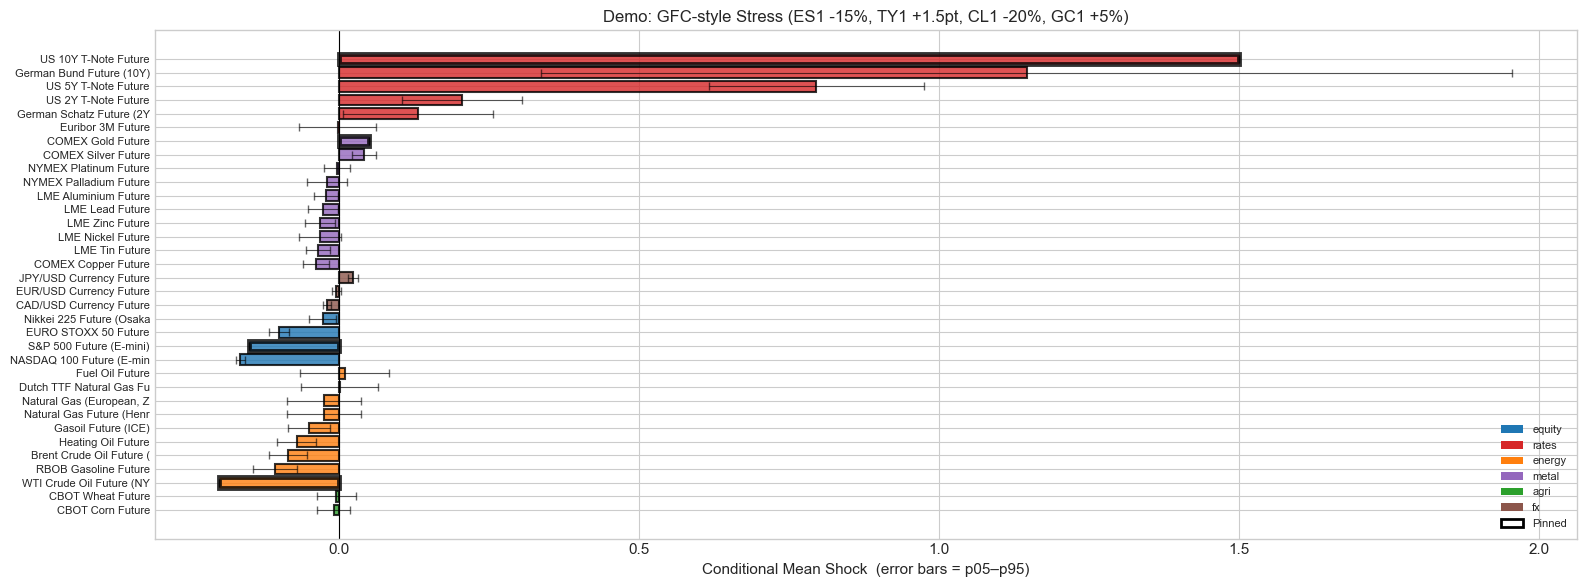

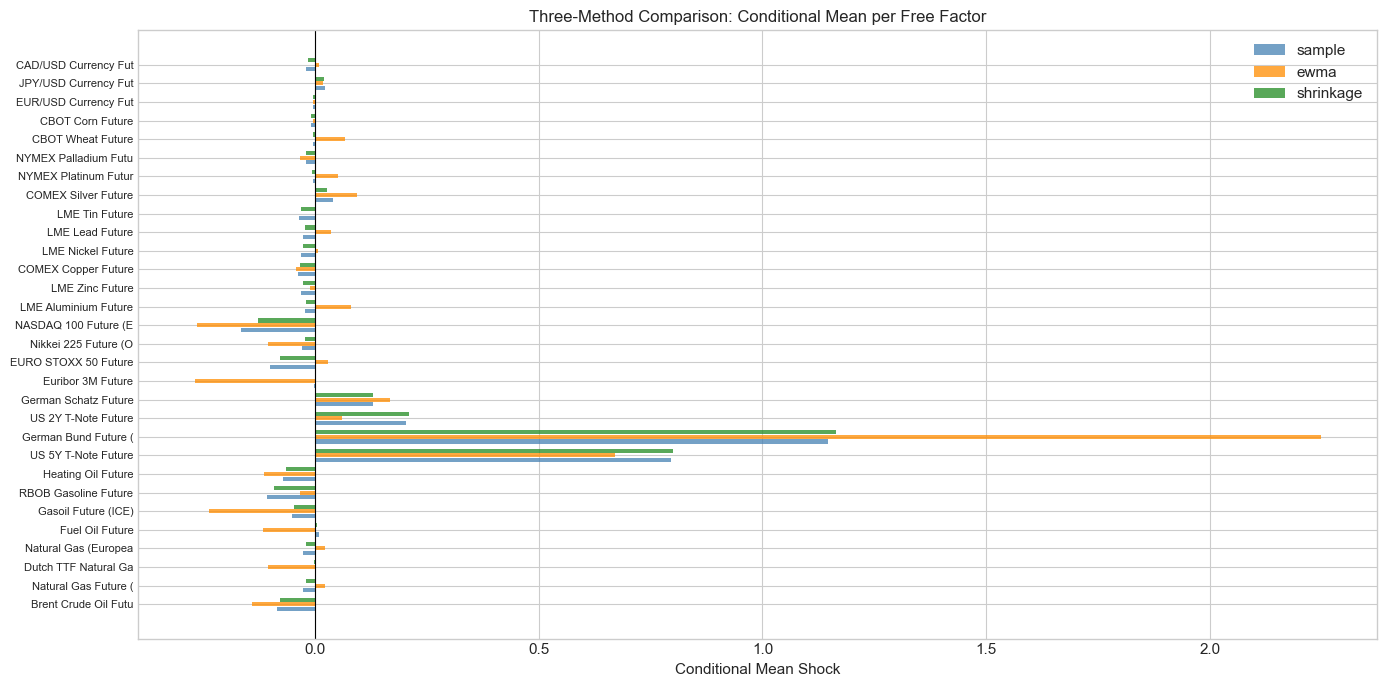

In [ ]:
def plot_scenario_result(result: ScenarioResult, title: str = ''):
    rows = []
    for fs in result.factor_results:
        if fs.is_pinned:
            p05 = p95 = fs.conditional_mean
        else:
            p05 = fs.conditional_mean + ss.norm.ppf(0.05) * fs.conditional_volatility
            p95 = fs.conditional_mean + ss.norm.ppf(0.95) * fs.conditional_volatility
        rows.append({
            'factor_name': fs.factor_name[:24],
            'asset_class': fs.asset_class,
            'cond_mean'  : fs.conditional_mean,
            'p05': p05, 'p95': p95,
            'is_pinned'  : fs.is_pinned,
        })
    df = pd.DataFrame(rows).sort_values(['asset_class', 'cond_mean'])

    fig, ax = plt.subplots(figsize=(16, 6))
    y_pos = range(len(df))
    colors = [CLASS_COLORS.get(r['asset_class'], 'gray') for _, r in df.iterrows()]
    edge   = ['black' if r['is_pinned'] else 'none' for _, r in df.iterrows()]
    width  = [3.5 if r['is_pinned'] else 1.5 for _, r in df.iterrows()]

    cond_means = df['cond_mean'].to_numpy()
    p05_arr    = df['p05'].to_numpy()
    p95_arr    = df['p95'].to_numpy()
    y_arr      = np.arange(len(df), dtype=float)

    ax.barh(y_arr, cond_means, color=colors,
            edgecolor=edge, linewidth=width, alpha=0.8)
    ax.errorbar(
        cond_means, y_arr,
        xerr=np.vstack([cond_means - p05_arr, p95_arr - cond_means]),
        fmt='none', color='black', capsize=3, linewidth=0.8, alpha=0.6
    )
    ax.set_yticks(y_arr)
    ax.set_yticklabels(df['factor_name'].tolist(), fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)

    # Legend patches
    from matplotlib.patches import Patch
    legend_els = [Patch(facecolor=c, label=cls) for cls, c in CLASS_COLORS.items()
                  if cls in df['asset_class'].values]
    legend_els.append(Patch(facecolor='white', edgecolor='black', linewidth=2, label='Pinned'))
    ax.legend(handles=legend_els, loc='lower right', fontsize=8)
    ax.set_xlabel('Conditional Mean Shock  (error bars = p05–p95)')
    ax.set_title(title or f'Scenario {result.scenario_id} — {result.method}')
    plt.tight_layout()
    plt.show()

plot_scenario_result(result_demo, 'Demo: GFC-style Stress (ES1 -15%, TY1 +1.5pt, CL1 -20%, GC1 +5%)')

# ── Three-method comparison ────────────────────────────────────────────────────
results_by_method = {}
for method in ['sample', 'ewma', 'shrinkage']:
    results_by_method[method] = conditional_gaussian_engine(
        returns_df=fit_df, transform_map=transform_map,
        scenario=DEMO_SCENARIO, cov_method=method,
    )

# Extract free-factor conditional means for comparison
free_names, means_by_method = [], {m: [] for m in results_by_method}
for fs in results_by_method['sample'].factor_results:
    if not fs.is_pinned:
        free_names.append(fs.factor_name[:20])
        means_by_method['sample'].append(fs.conditional_mean)
for method in ['ewma', 'shrinkage']:
    for fs in results_by_method[method].factor_results:
        if not fs.is_pinned:
            means_by_method[method].append(fs.conditional_mean)

y_pos = np.arange(len(free_names))
fig, ax = plt.subplots(figsize=(14, 7))
colors3 = ['steelblue', 'darkorange', 'forestgreen']
for k, (method, color) in enumerate(zip(['sample', 'ewma', 'shrinkage'], colors3)):
    ax.barh(y_pos - 0.25 + k*0.25, means_by_method[method], height=0.22,
            label=method, color=color, alpha=0.75)
ax.set_yticks(y_pos)
ax.set_yticklabels(free_names, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.legend()
ax.set_title('Three-Method Comparison: Conditional Mean per Free Factor')
ax.set_xlabel('Conditional Mean Shock')
plt.tight_layout()
plt.show()


## §14  Model Sanity Checks

Per `docs/04_validation_design.md` — Model Sanity Layer.


In [ ]:
def run_sanity_checks(result: ScenarioResult, scenario: dict, cov_df: pd.DataFrame) -> dict:
    checks = {}

    # 1. Condition number
    cond = result.diagnostics.get('condition_number', None)
    checks['cond_num_ok'] = cond is not None and cond < 1e12

    # 2. PSD of Σ_B|A  (check min eigenvalue of cov sub-block)
    free_tickers = [fs.factor_name for fs in result.factor_results if not fs.is_pinned]
    pinned_tickers = list(scenario.keys())
    free_in_cov = [t for t in free_tickers if t in cov_df.index]
    if len(free_in_cov) >= 2:
        Sigma_BB_sub = cov_df.loc[free_in_cov, free_in_cov].values
        Sigma_BA_sub = cov_df.loc[free_in_cov, pinned_tickers].values
        inv_AA_sub, _, _ = safe_inv(cov_df.loc[pinned_tickers, pinned_tickers].values)
        Sigma_cond_sub = Sigma_BB_sub - Sigma_BA_sub @ inv_AA_sub @ Sigma_BA_sub.T
        min_ev = np.linalg.eigvalsh(Sigma_cond_sub).min()
        checks['sigma_cond_psd'] = min_ev > -1e-8
        checks['sigma_cond_min_ev'] = float(min_ev)
    else:
        checks['sigma_cond_psd'] = None

    # 3. Pinned factor accuracy (output should = input shock)
    pinned_ok = True
    for fs in result.factor_results:
        if fs.is_pinned:
            if abs(fs.conditional_mean - fs.input_shock) > 1e-10:
                pinned_ok = False
    checks['pinned_exact'] = pinned_ok

    # 4. Quantile monotonicity
    mono_ok = True
    for fs in result.factor_results:
        if not fs.is_pinned and fs.conditional_volatility > 0:
            vals = [fs.conditional_mean + ss.norm.ppf(p) * fs.conditional_volatility
                    for p in [0.05, 0.25, 0.50, 0.75, 0.95]]
            mono_ok = mono_ok and all(vals[i] <= vals[i+1] for i in range(len(vals)-1))
    checks['quantile_monotone'] = mono_ok

    # 5. ScenarioResult schema completeness
    required = ['condition_number', 'observation_count', 'mahalanobis_distance']
    checks['schema_complete'] = all(k in result.diagnostics for k in required)

    # 6. Mahalanobis: is the scenario historically extreme?
    mahal = result.diagnostics.get('mahalanobis_distance', 0)
    n_pinned = result.diagnostics.get('n_pinned', len(scenario))
    chi2_95 = ss.chi2.ppf(0.95, df=n_pinned)
    checks['scenario_in_95pct_chi2'] = mahal < chi2_95
    checks['mahalanobis'] = round(mahal, 3)
    checks['chi2_95_threshold'] = round(chi2_95, 3)

    return checks

checks = run_sanity_checks(result_demo, DEMO_SCENARIO, sample_cov)

print('═══ Sanity Check Results ═══')
icons = {True: '✓', False: '✖', None: '?'}
for k, v in checks.items():
    icon = icons.get(v, '—') if isinstance(v, bool) or v is None else '—'
    print(f'  {icon}  {k:<35s} {v}')


═══ Sanity Check Results ═══
  ✓  cond_num_ok                         True
  ?  sigma_cond_psd                      None
  ✓  pinned_exact                        True
  ✓  quantile_monotone                   True
  ✓  schema_complete                     True
  —  scenario_in_95pct_chi2              False
  —  mahalanobis                         229.846
  —  chi2_95_threshold                   9.488


## §15  Historical Replay Validation

**Protocol (per `docs/04_validation_design.md`):**
1. Select event window from `configs/stress_episodes.yaml`
2. Fit covariance on data ending **before** event start
3. Compute realized shocks (cumulative returns) in event window
4. Pin 3 representative factors; compare engine output vs realized

**Metrics:** Direction Accuracy, MAE, Rank Correlation


In [ ]:
def historical_replay(
    episode_id: str,
    pin_tickers: list,
    returns_df: pd.DataFrame,
    transform_map: dict,
    cov_method: str = 'sample',
    fit_global_start: str = '2010-01-01',
) -> dict:
    """Run one historical replay episode."""
    # Get episode from config
    ep = next((e for e in EPISODES_CFG['episodes'] if e['episode_id'] == episode_id), None)
    if ep is None:
        raise ValueError(f'Episode {episode_id} not found')

    ev_start = str(ep['start_date'])
    ev_end   = str(ep['end_date'])
    fit_end  = pd.Timestamp(ev_start) - pd.Timedelta(days=1)

    # Fit window: global start → day before event
    fit_window = returns_df.loc[fit_global_start:str(fit_end.date())].dropna()
    if len(fit_window) < 252:
        return {'error': f'Only {len(fit_window)} obs in fit window — too few'}

    # Realized shocks: cumulative return in event window
    event_rets = returns_df.loc[ev_start:ev_end]
    realized   = event_rets.sum()   # cumulative

    # Filter pin tickers to those available
    available_pins = [t for t in pin_tickers if t in realized.index and t in fit_window.columns]
    if len(available_pins) < 2:
        return {'error': 'Insufficient pin tickers in data'}

    scenario_ep = {t: {'shock': float(realized[t]), 'unit': transform_map.get(t, 'return')}
                   for t in available_pins}

    # Run engine on pre-event fit window
    result_ep = conditional_gaussian_engine(
        returns_df=fit_window, transform_map=transform_map,
        scenario=scenario_ep, cov_method=cov_method, fit_start=fit_global_start,
    )

    # Compare generated vs realized for free factors
    # Map factor_id (snake_case) back to BB ticker for lookup
    _fid = lambda t: t.replace(' ', '_').lower().replace('.', '_')
    gen_by_fid = {fs.factor_id: fs.conditional_mean
                  for fs in result_ep.factor_results if not fs.is_pinned}
    free_tickers = [t for t in realized.index
                    if t not in available_pins and _fid(t) in gen_by_fid]

    gen_vals  = np.array([gen_by_fid[_fid(t)] for t in free_tickers])
    real_vals = np.array([realized[t] for t in free_tickers])

    # Metrics
    dir_accuracy = np.mean(np.sign(gen_vals) == np.sign(real_vals)) * 100
    mae = np.mean(np.abs(gen_vals - real_vals))
    rank_corr, _ = ss.spearmanr(gen_vals, real_vals)

    # Tail miss: how many free factors have realized shock outside p05–p95?
    tail_miss = 0
    for fs in result_ep.factor_results:
        if not fs.is_pinned and fs.factor_name in free_tickers:
            real_shock = realized.get(fs.factor_name, np.nan)
            if not np.isnan(real_shock) and fs.conditional_volatility > 0:
                p05 = fs.conditional_mean + ss.norm.ppf(0.05) * fs.conditional_volatility
                p95 = fs.conditional_mean + ss.norm.ppf(0.95) * fs.conditional_volatility
                if real_shock < p05 or real_shock > p95:
                    tail_miss += 1

    return {
        'episode'       : ep['name'],
        'event_window'  : f'{ev_start} → {ev_end}',
        'fit_obs'       : len(fit_window),
        'pinned_factors': available_pins,
        'n_free'        : len(free_tickers),
        'direction_acc' : f'{dir_accuracy:.1f}%',
        'mae'           : f'{mae:.5f}',
        'rank_corr'     : f'{rank_corr:.3f}',
        'tail_miss'     : tail_miss,
        'tail_miss_pct' : f'{tail_miss/len(free_tickers)*100:.1f}%' if free_tickers else '?',
        'warnings'      : len(result_ep.warnings),
        'mahalanobis'   : round(result_ep.diagnostics.get('mahalanobis_distance', 0), 3),
    }

PIN_TICKERS_DEFAULT = ['ES1 Index', 'TY1 Comdty', 'CL1 Comdty']

print('Running historical replay episodes ...')
print('(Using Ledoit-Wolf covariance for numerical stability in replay)')
for episode_id in ['covid_shock_2020', 'rates_selloff_2022']:
    print(f'\n── {episode_id} ─────────────────────────────────────────────────')
    replay_result = historical_replay(
        episode_id=episode_id,
        pin_tickers=PIN_TICKERS_DEFAULT,
        returns_df=returns_df,   # full returns (not just fit_df) so replay has pre-event window
        transform_map=transform_map,
        cov_method='shrinkage',   # better condition number for numerical stability
    )
    if 'error' in replay_result:
        print(f'  ERROR: {replay_result["error"]}')
    else:
        for k, v in replay_result.items():
            print(f'  {k:<22s} {v}')


Running historical replay episodes ...
(Using Ledoit-Wolf covariance for numerical stability in replay)

── covid_shock_2020 ─────────────────────────────────────────────────
  episode                COVID market shock
  event_window           2020-02-20 → 2020-03-23
  fit_obs                2633
  pinned_factors         ['ES1 Index', 'TY1 Comdty', 'CL1 Comdty']
  n_free                 31
  direction_acc          93.5%
  mae                    0.52176
  rank_corr              0.677
  tail_miss              0
  tail_miss_pct          0.0%
  warnings               3
  mahalanobis            1788.606

── rates_selloff_2022 ─────────────────────────────────────────────────
  episode                2022 rates selloff
  event_window           2022-08-01 → 2022-10-21
  fit_obs                3266
  pinned_factors         ['ES1 Index', 'TY1 Comdty', 'CL1 Comdty']
  n_free                 31
  direction_acc          54.8%
  mae                    0.78623
  rank_corr              0.413
  tail_m

## §16  Interactive Dashboard

**UI adapted from Tony's ipywidgets framework** — replaced:
- Data source: BB tickers instead of Yahoo tickers  
- Engine: §11 `conditional_gaussian_engine()` instead of inline functions  
- Output: shows `conditional_vol` and `p05/p95` (Tony only showed `implied_return`)  
- Status card: OK / Warning / Review Required (Tony's color logic preserved)

Run the cell to launch the dashboard in Jupyter.


In [ ]:
# ─── §16  Interactive Dashboard ───────────────────────────────────────────────
# Design: PRESET SCENARIOS as primary entry point → per-asset-class factor rows
# Three output tabs: Results | Three-Method Comparison | Diagnostics
#
# Aiden's layout differs from Tony's (searchable list + dynamic pin) in that
# demos are preset-first: pick a named scenario, tweak shocks, see all three
# covariance methods side-by-side.
# ──────────────────────────────────────────────────────────────────────────────
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print('ipywidgets not available — install with: pip install ipywidgets')

if not WIDGETS_AVAILABLE:
    print('Skipping dashboard — ipywidgets not installed.')
else:
    # ── 1. Preset scenario catalogue ─────────────────────────────────────────
    PRESETS = {
        '(custom — clear all)': {},
        'GFC-style 2008 (equity crash + oil crash + flight-to-quality)': {
            'ES1 Index':   {'shock': -0.15, 'unit': 'return'},
            'TY1 Comdty':  {'shock':  1.50, 'unit': 'price_diff'},
            'CL1 Comdty':  {'shock': -0.20, 'unit': 'return'},
            'GC1 Comdty':  {'shock':  0.05, 'unit': 'return'},
        },
        'COVID shock (Feb-Mar 2020 severity)': {
            'ES1 Index':   {'shock': -0.30, 'unit': 'return'},
            'TY1 Comdty':  {'shock':  3.00, 'unit': 'price_diff'},
            'CL1 Comdty':  {'shock': -0.55, 'unit': 'return'},
        },
        '2022 Rates selloff (inflation + tightening)': {
            'TY1 Comdty':  {'shock': -4.00, 'unit': 'price_diff'},
            'DU1 Comdty':  {'shock': -2.00, 'unit': 'price_diff'},
            'ES1 Index':   {'shock': -0.10, 'unit': 'return'},
            'CO1 Comdty':  {'shock':  0.08, 'unit': 'return'},
        },
        'China demand shock (commodity supply squeeze)': {
            'CO1 Comdty':  {'shock':  0.12, 'unit': 'return'},
            'CL1 Comdty':  {'shock':  0.10, 'unit': 'return'},
            'NG1 Comdty':  {'shock':  0.08, 'unit': 'return'},
            'HG1 Comdty':  {'shock': -0.10, 'unit': 'return'},
            'ES1 Index':   {'shock': -0.05, 'unit': 'return'},
        },
        'Dollar squeeze (USD strength shock)': {
            'DX1 Curncy':  {'shock':  0.05, 'unit': 'return'},
            'GC1 Comdty':  {'shock': -0.04, 'unit': 'return'},
            'CO1 Comdty':  {'shock': -0.06, 'unit': 'return'},
        },
    }
    PRESET_NAMES = list(PRESETS.keys())

    # asset-class ordering for the factor grid
    CLASS_ORDER = ['equity', 'rates', 'energy', 'metal', 'agri', 'fx', 'other']
    def _sort_key(t):
        ac = ASSET_CLASS.get(t, 'other')
        return (CLASS_ORDER.index(ac) if ac in CLASS_ORDER else len(CLASS_ORDER), t)
    SORTED_TICKERS = sorted(TIER_A, key=_sort_key)

    # ── 2. Shared helpers (defined first — used in widget construction) ─────────
    CLASS_COLORS = {
        'equity': '#1a6fbf', 'rates': '#c0392b', 'energy': '#e67e22',
        'metal': '#8e44ad', 'agri': '#27ae60', 'fx': '#16a085', 'other': '#7f8c8d',
    }

    def _status_html(state, msg=''):
        styles = {
            'idle':    ('gray',      '○  Ready'),
            'ok':      ('green',     '✓  OK'),
            'warn':    ('darkorange','⚠  Warnings'),
            'error':   ('red',       '✖  Error'),
        }
        col, label = styles.get(state, styles['idle'])
        return (f"<span style='color:{col};font-weight:600;font-size:13px;'>"
                f"{label}</span>"
                + (f" — {msg}" if msg else ''))

    def _make_label(ticker):
        ac   = ASSET_CLASS.get(ticker, 'other')
        name = FACTOR_META.get(ticker, {}).get('factor_name', ticker)
        col  = CLASS_COLORS.get(ac, '#555')
        return (f"<span style='color:{col};font-weight:600;font-size:12px;'>"
                f"[{ac.upper()}]</span> "
                f"<span style='font-size:12px;'>{ticker}</span> "
                f"<span style='color:#888;font-size:11px;'>— {name}</span>")

    # ── 3. Factor row widgets (one per Tier-A ticker) ─────────────────────────
    factor_rows = {}
    for t in SORTED_TICKERS:
        check = widgets.Checkbox(
            value=False, description='',
            layout=widgets.Layout(width='30px', margin='0'),
        )
        shock = widgets.FloatText(
            value=0.0, description='',
            layout=widgets.Layout(width='110px'),
        )
        factor_rows[t] = {'check': check, 'shock': shock}

    # ── 4. Top-level control widgets ─────────────────────────────────────────
    preset_dd = widgets.Dropdown(
        options=PRESET_NAMES, value=PRESET_NAMES[0],
        description='Preset:',
        style={'description_width': '55px'},
        layout=widgets.Layout(width='520px'),
    )

    scenario_name = widgets.Text(
        value='My scenario',
        description='Name:',
        style={'description_width': '45px'},
        layout=widgets.Layout(width='300px'),
    )

    run_btn    = widgets.Button(description='▶  Run', button_style='primary',
                                layout=widgets.Layout(width='120px', height='36px'))
    compare_btn = widgets.Button(description='⊞  Compare 3 methods',
                                 button_style='info',
                                 layout=widgets.Layout(width='190px', height='36px'))
    clear_btn  = widgets.Button(description='✕  Clear', button_style='warning',
                                layout=widgets.Layout(width='110px', height='36px'))

    status_bar = widgets.HTML(value=_status_html('idle'))

    # ── 5. Output tabs ───────────────────────────────────────────────────────
    out_results = widgets.Output()
    out_compare = widgets.Output()
    out_diag    = widgets.Output()
    out_tabs = widgets.Tab(children=[out_results, out_compare, out_diag])
    out_tabs.set_title(0, 'Results')
    out_tabs.set_title(1, 'Compare 3 Methods')
    out_tabs.set_title(2, 'Diagnostics')

    # ── 6. Helper: gather pinned scenario from widget state ───────────────────
    def _gather_scenario():
        sc = {}
        for t, row in factor_rows.items():
            if row['check'].value:
                sc[t] = {'shock': row['shock'].value,
                          'unit': transform_map.get(t, 'return')}
        return sc

    # ── 7. Apply preset callback ─────────────────────────────────────────────
    def _apply_preset(change=None):
        preset = PRESETS.get(preset_dd.value, {})
        for t, row in factor_rows.items():
            if t in preset:
                row['check'].value = True
                row['shock'].value = preset[t]['shock']
            else:
                row['check'].value = False
                row['shock'].value = 0.0
        status_bar.value = _status_html('idle', f'Preset loaded: {preset_dd.value[:50]}')

    preset_dd.observe(_apply_preset, names='value')

    # ── 8. Run (single method) ────────────────────────────────────────────────
    def _run(btn=None):
        sc = _gather_scenario()
        if not sc:
            status_bar.value = _status_html('warn', 'No factors pinned — select at least one.')
            return
        try:
            res = conditional_gaussian_engine(
                returns_df=fit_df, transform_map=transform_map,
                scenario=sc, cov_method='shrinkage',
            )
            n_err  = sum(1 for w in res.warnings if w.severity == 'error')
            n_warn = sum(1 for w in res.warnings if w.severity == 'warning')
            state  = 'error' if n_err else ('warn' if n_warn else 'ok')
            mah    = res.diagnostics.get('mahalanobis', float('nan'))
            status_bar.value = _status_html(
                state,
                f'{len(sc)} pinned | Mahal={mah:.2f} | '
                f'{n_warn}W {n_err}E | method=Ledoit-Wolf'
            )
            with out_results:
                clear_output(wait=True)
                display_scenario_result(res, top_n=len(TIER_A))
                plot_scenario_result(res, title=f'{scenario_name.value}  [Ledoit-Wolf]')
            out_tabs.selected_index = 0
        except Exception as e:
            status_bar.value = _status_html('error', str(e))

    # ── 9. Compare all three covariance methods ───────────────────────────────
    def _compare(btn=None):
        sc = _gather_scenario()
        if not sc:
            status_bar.value = _status_html('warn', 'No factors pinned.')
            return
        methods = [('sample', 'Sample'), ('ewma', 'EWMA λ=0.94'), ('shrinkage', 'Ledoit-Wolf')]
        results = {}
        for mkey, mlabel in methods:
            try:
                results[mlabel] = conditional_gaussian_engine(
                    returns_df=fit_df, transform_map=transform_map,
                    scenario=sc, cov_method=mkey,
                )
            except Exception as e:
                results[mlabel] = None
        with out_compare:
            clear_output(wait=True)
            plot_scenario_result(list(results.values())[2],  # LW as primary
                                 title=f'{scenario_name.value} — 3-method comparison')
            # Tabular comparison
            rows_cmp = []
            for t in SORTED_TICKERS:
                fname = FACTOR_META.get(t, {}).get('factor_name', t)
                is_pin = t in sc
                row_d  = {'Factor': fname, 'Pinned': '★' if is_pin else ''}
                for mlabel, res in results.items():
                    if res is None:
                        row_d[mlabel] = 'ERR'
                        continue
                    fr = next((f for f in res.factor_results
                                if f.factor_id == t.replace(' ','_').lower().replace('.','_')),
                              None)
                    if fr:
                        row_d[mlabel] = (f'{fr.conditional_mean:+.4f}' if fr.conditional_mean is not None
                                         else '—')
                    else:
                        row_d[mlabel] = '—'
                rows_cmp.append(row_d)
            df_cmp = pd.DataFrame(rows_cmp)
            print(df_cmp.to_string(index=False))
        with out_diag:
            clear_output(wait=True)
            print(f'=== Diagnostics: {scenario_name.value} ===')
            hdr = f'{{:<22}} {{:>14}} {{:>14}} {{:>14}}'.format(
                      'Metric', *[m[1] for m in methods])
            print(hdr); print('-'*70)
            diag_keys = ['cond_num', 'min_eigenvalue', 'mahalanobis', 'n_warnings']
            for key in diag_keys:
                vals = []
                for _, res in results.items():
                    if res is None: vals.append('ERR'); continue
                    v = res.diagnostics.get(key, '—')
                    vals.append(f'{v:.3g}' if isinstance(v, float) else str(v))
                print(f'{{:<22}} {{:>14}} {{:>14}} {{:>14}}'.format(key, *vals))
            print()
            for mlabel, res in results.items():
                if res and res.warnings:
                    print(f'Warnings [{mlabel}]:')
                    for w in res.warnings:
                        print(f'  [{w.severity}] {w.factor_id}: {w.message}')
        out_tabs.selected_index = 1
        status_bar.value = _status_html('ok', '3-method comparison done.')

    # ── 10. Clear all ─────────────────────────────────────────────────────────
    def _clear(btn=None):
        for row in factor_rows.values():
            row['check'].value = False
            row['shock'].value = 0.0
        status_bar.value = _status_html('idle', 'Cleared.')
        for out in [out_results, out_compare, out_diag]:
            with out: clear_output()

    run_btn.on_click(_run)
    compare_btn.on_click(_compare)
    clear_btn.on_click(_clear)

    # ── 11. Factor grid (grouped by asset class) ──────────────────────────────
    def _make_factor_grid():
        sections = []
        current_class = None
        group_rows = []
        for t in SORTED_TICKERS:
            ac = ASSET_CLASS.get(t, 'other')
            if ac != current_class:
                if group_rows:
                    sections.append(widgets.VBox(group_rows,
                        layout=widgets.Layout(margin='0 0 6px 0')))
                col = CLASS_COLORS.get(ac, '#555')
                sections.append(widgets.HTML(
                    f"<div style='background:{col}15;border-left:3px solid {col};"
                    f"padding:2px 8px;margin:6px 0 2px 0;font-weight:700;"
                    f"font-size:12px;color:{col}'>{ac.upper()}</div>"
                ))
                current_class = ac
                group_rows = []
            row = factor_rows[t]
            lbl = widgets.HTML(_make_label(t), layout=widgets.Layout(width='480px'))
            unit_lbl = widgets.Label(
                f'[{transform_map.get(t, "return")}]',
                layout=widgets.Layout(width='90px', color='#888'),
            )
            group_rows.append(widgets.HBox(
                [row['check'], lbl, row['shock'], unit_lbl],
                layout=widgets.Layout(align_items='center', margin='1px 0'),
            ))
        if group_rows:
            sections.append(widgets.VBox(group_rows))
        return widgets.VBox(sections, layout=widgets.Layout(
            overflow_y='auto', max_height='420px',
            border='1px solid #ddd', padding='8px', border_radius='4px',
        ))

    factor_grid = _make_factor_grid()

    # ── 12. Assemble final UI ─────────────────────────────────────────────────
    header = widgets.HTML(
        "<h3 style='margin:0;font-family:sans-serif;color:#1a1a2e;'>"
        "Conditional Gaussian Scenario Engine</h3>"
        "<p style='margin:2px 0 8px 0;color:#555;font-size:12px;'>"
        "RBC Capital Markets — Cross-Asset Stress Scenario Generator  |  "
        "Tier-A universe · 34 factors · 3 covariance methods</p>"
    )

    preset_row = widgets.HBox(
        [preset_dd, scenario_name],
        layout=widgets.Layout(gap='16px', margin='0 0 6px 0'),
    )
    btn_row = widgets.HBox(
        [run_btn, compare_btn, clear_btn],
        layout=widgets.Layout(gap='10px', margin='6px 0'),
    )

    left_panel = widgets.VBox(
        [widgets.HTML("<b style='font-size:12px;'>Pin Factors (by Asset Class):</b>"),
         factor_grid],
        layout=widgets.Layout(width='760px'),
    )

    ui = widgets.VBox([
        header,
        widgets.HTML("<hr style='margin:4px 0;border-color:#e0e0e0;'>"),
        preset_row,
        btn_row,
        status_bar,
        widgets.HTML("<hr style='margin:4px 0;border-color:#e0e0e0;'>"),
        left_panel,
        widgets.HTML("<hr style='margin:8px 0;border-color:#e0e0e0;'>"),
        out_tabs,
    ], layout=widgets.Layout(padding='12px', border='1px solid #ccc',
                              border_radius='6px', max_width='800px'))

    display(ui)
    # Load the first real preset to demonstrate
    preset_dd.value = PRESET_NAMES[1]   # GFC scenario
    print('Dashboard ready — select a preset or pin factors manually, then click ▶ Run.')


Dashboard ready — select a preset or pin factors manually, then click ▶ Run.


---

## Next Steps & Bloomberg Pull Requests

**For Mo's next Bloomberg pull (Mezan 06-18 recommendations):**

| Data | Bloomberg Tickers | Purpose |
|------|------------------|---------|
| Major equity spot indices | SPX Index, SX5E Index, UKX Index, NKY Index | Roll-free equity reference |
| Gold spot | XAUUSD Curncy | Non-futures commodity price |
| Second-month futures | CL2, TY2, ES2, NG2 etc. | Roll Method B adjustment |
| Volume + OI (confirm complete) | Already in BB_Cleaned | Roll detection validation |

**Open decisions for Mezan (Tuesday 06-23):**

1. **Roll treatment**: Method A (flag/exclude) vs B (ratio-adjust) vs C (active contract)?
2. **High-corr pairs**: Which pairs to collapse — CO1/CL1, FV1/TY1, DU1/RX1?
3. **Metadata audit**: Send Excel — ZMI1 = micro corn? BMR1, DCR1 = ?
4. **Fit window**: Confirm 2010-01-01 as start, or use different anchor?
